<a href="https://colab.research.google.com/github/Emanuel2234/Causas_muerte_chile_2023_2026/blob/main/Causas_de_Defunci%C3%B3n_chile_2023_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis mineria de datos : Causas de muerte en chile periodo 2023 a 03/2026

Se realiza analsis a casos de muerte en chile en base a un dataset del minsal que cubren el periodo 2023 a marzo del 2026, en el cual veremos las principales causas de muerte en nuestro pais y asi analizar es estilo de vida de los chilenos y chilenas otra cosa que podemos rescatar es la edad a la que muere la poblacion chilena.

Enlace de Fuente: https://deis.minsal.cl/#datosabiertos

**Estudiante: Emanuel Farias**

**Curso: MINERIA DE DATOS**

**Seccion: 004D**

**Profesor: Carlos Muñoz**


# Fase 1: entendimiento del negocio
El objetivo aquí es entender el fenómeno de la mortalidad desde una perspectiva social. Queremos saber de qué estamos muriendo realmente y si factores como el género, el lugar de la defunción o la edad tienen una relación directa que podamos modelar para mejorar la toma de decisiones en salud pública.

In [ ]:
# ============================================================
# LIBRERÍAS
# ============================================================
!pip install kneed
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelos de Machine Learning
from sklearn.linear_model import LinearRegression          # Regresión Lineal Múltiple
from sklearn.tree import DecisionTreeRegressor, export_text # Árbol de Decisión + extracción de reglas

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, r2_score  # MAE y R²

# K-Means y métricas de agrupamiento
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Comprensión de los Datos
En esta parte cargamos el dataset del DEIS y revisamos qué tenemos. Nos encontramos con un volumen importante de información: 407,897 registros y 28 columnas iniciales.

In [ ]:
#se importa el dataset
df = pd.read_csv('/content/DEFUNCIONES_FUENTE_DEIS_2023_2026_14042026.csv', encoding='latin-1', sep=';')

In [ ]:
df.shape # se logra apreciar 407897 filas y 28 columnas

(407897, 27)

In [ ]:
df.columns

Index(['AÑO', 'FECHA_DEF', 'SEXO_NOMBRE', 'EDAD_TIPO', 'EDAD_CANT',
       'COD_COMUNA', 'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1',
       'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1',
       'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1',
       'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2',
       'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2',
       'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2',
       'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2',
       'LUGAR_DEFUNCION'],
      dtype='object')

Aqui se puede ver las columnas que proveiene de este dataset de las cuales podemos decir:

AÑO: año de la defucion (variable númerica).

FECHA_DEF: fecha completa de la misma (variables categoricas).

EDAD_CANT: edad del fallecido (variable númerica).

SEXO: genero del fallecido/a(variables categoricas).

EDAD_TIPO: codigo que indica la unidad de medida (variables categoricas).

NOMBRE_REGION, COMUNA y COD_COMUNA: idicacion de donde ocurrio (variables categoricas).

LUGAR_DEFUNCION: indica si ocurrio en casa, hospital o via publica (variables categoricas).

DIAG1: corresponde al codigo alfanumerico de la enfermedad o condicion (variables categoricas).

GLOSA_CAPITULO_DIAG1:este seria el apartado donde dice que enfermedad es segun el codigo (variables categoricas).

CAPITULO_DIAG1: numero de los capitulos medicos (variables categoricas).

CODIGO_CATEGORIA_DIAG1: codigo jerarquico del diagnostico (variables categoricas).

DIAG2 y sus derivados: trata de los mismo que el diag1 pero solo que es en base a causas externas del fallecimiento, para todas sus dereivadas y la misma es (variables categoricas)

EDAD: variable limpia de la edad cronologica en años (variable númerica).

Causa_Principal: variable target, es la clasificacion agrupada de la causa de muerte (variables categoricas).



In [ ]:
df.head()

,AÑO,FECHA_DEF,SEXO_NOMBRE,EDAD_TIPO,EDAD_CANT,COD_COMUNA,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,...,DIAG2,CAPITULO_DIAG2,GLOSA_CAPITULO_DIAG2,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION
0,2026,23-03-2026,Hombre,1,64,13129.0,San Joaquín,Metropolitana de Santiago,I10X,I00-I99,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
1,2026,07-03-2026,Hombre,1,71,14107.0,Paillaco,De Los Ríos,C61X,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
2,2026,09-03-2026,Mujer,1,72,8112.0,Hualpén,Del Bíobío,J841,J00-J99,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica
3,2026,18-01-2026,Hombre,1,70,5801.0,Quilpué,De Valparaíso,C719,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación
4,2026,08-03-2026,Mujer,1,75,13114.0,Las Condes,Metropolitana de Santiago,C56X,C00-D48,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación


le hechamos un pequeño vistazo al contenido del dataset para familiarizarnos con los datos

In [ ]:
# Aseguramos que la Edad sea numérica y renombramos el Sexo
df['EDAD'] = pd.to_numeric(df['EDAD_CANT'], errors='coerce')
df.rename(columns={'SEXO_NOMBRE': 'SEXO'}, inplace=True)

In [ ]:
# convertimos a formato fecha por si acaso
df['FECHA_DEF'] = pd.to_datetime(df['FECHA_DEF'])

# extraemos el número del mes
df['MES'] = df['FECHA_DEF'].dt.month

meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
df['MES_NOMBRE'] = df['MES'].map(meses_es)


print(df[['FECHA_DEF', 'MES', 'MES_NOMBRE']].head())

   FECHA_DEF  MES MES_NOMBRE
0 2026-03-23    3      Marzo
1 2026-03-07    3      Marzo
2 2026-03-09    3      Marzo
3 2026-01-18    1      Enero
4 2026-03-08    3      Marzo


In [ ]:
# lista de columnas a eliminar
columnas_a_eliminar = ['EDAD_TIPO', 'COD_COMUNA', 'FECHA_DEF']

# eliminación de las columnas
# axis=1 indica que estamos eliminando columnas, no filas
# inplace=True aplica los cambios directamente al DataFrame original
df.drop(columns=columnas_a_eliminar, axis=1, inplace=True, errors='ignore')

# verificamos cómo quedó el DataFrame
print("Columnas restantes después de la limpieza:")
print(df.columns.tolist())

# mostramos las primeras filas para confirmar
df.head()

Columnas restantes después de la limpieza:
['AÑO', 'SEXO', 'EDAD_CANT', 'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1', 'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1', 'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1', 'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2', 'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2', 'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2', 'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2', 'LUGAR_DEFUNCION', 'EDAD', 'MES', 'MES_NOMBRE']


,AÑO,SEXO,EDAD_CANT,COMUNA,NOMBRE_REGION,DIAG1,CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG1,CODIGO_GRUPO_DIAG1,GLOSA_GRUPO_DIAG1,...,CODIGO_GRUPO_DIAG2,GLOSA_GRUPO_DIAG2,CODIGO_CATEGORIA_DIAG2,GLOSA_CATEGORIA_DIAG2,CODIGO_SUBCATEGORIA_DIAG2,GLOSA_SUBCATEGORIA_DIAG2,LUGAR_DEFUNCION,EDAD,MES,MES_NOMBRE
0,2026,Hombre,64,San Joaquín,Metropolitana de Santiago,I10X,I00-I99,Enfermedades del sistema circulatorio,I10-I15,Enfermedades hipertensivas,...,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,64,3,Marzo
1,2026,Hombre,71,Paillaco,De Los Ríos,C61X,C00-D48,Tumores [Neoplasias],C60-C63,Tumores malignos de los órganos genitales masc...,...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,71,3,Marzo
2,2026,Mujer,72,Hualpén,Del Bíobío,J841,J00-J99,Enfermedades del sistema respiratorio,J80-J84,Otras enfermedades respiratorias que afectan p...,...,NaN,NaN,NaN,NaN,NaN,NaN,Hospital o Clínica,72,3,Marzo
3,2026,Hombre,70,Quilpué,De Valparaíso,C719,C00-D48,Tumores [Neoplasias],C69-C72,"Tumores malignos del ojo, del encéfalo y de ot...",...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,70,1,Enero
4,2026,Mujer,75,Las Condes,Metropolitana de Santiago,C56X,C00-D48,Tumores [Neoplasias],C51-C58,Tumores malignos de los órganos genitales feme...,...,NaN,NaN,NaN,NaN,NaN,NaN,Casa habitación,75,3,Marzo


In [ ]:
df.isna().sum()

,0
AÑO,0
SEXO,0
EDAD_CANT,0
COMUNA,63
NOMBRE_REGION,63
DIAG1,0
CAPITULO_DIAG1,4
GLOSA_CAPITULO_DIAG1,4
CODIGO_GRUPO_DIAG1,4
GLOSA_GRUPO_DIAG1,4


# Se logra percibir que todas estas variables poseen nulos

COD_COMUNA

COMUNA

NOMBRE_REGION

GLOSA_CAPITULO_DIAG1

CODIGO_GRUPO_DIAG1

GLOSA_CATEGORIA_DIAG1

CODIGO_SUBCATEGORIA_DIAG1

GLOSA_SUBCATEGORIA_DIAG1

DIAG2

CAPITULO_DIAG2

GLOSA_CAPITULO_DIAG2

CODIGO_GRUPO_DIAG2

GLOSA_GRUPO_DIAG2

CODIGO_CATEGORIA_DIAG2

GLOSA_CATEGORIA_DIAG2

CODIGO_SUBCATEGORIA_DIAG2

GLOSA_SUBCATEGORIA_DIAG2



una de las posibles causas de que haya tantos nulos en los DIAG2 es que puede haber muerto de causas naturales por lo que esa seccion no era necesario llenarla.

la los de comuna y nombre_region podria deberse a las personas en situacion de calle, tambien si fueron extrajeros o transeuntes que su residencia no esta en chile tal cual.



In [ ]:
df.describe().round() # se le aplica estadistica a columnas numericas

,AÑO,EDAD_CANT,EDAD,MES
count,407897.0,407897.0,407897.0,407897.0
mean,2024.0,73.0,73.0,6.0
std,1.0,18.0,18.0,3.0
min,2023.0,0.0,0.0,1.0
25%,2023.0,65.0,65.0,3.0
50%,2024.0,77.0,77.0,6.0
75%,2025.0,86.0,86.0,9.0
max,2026.0,140.0,140.0,12.0


al comienzo se logra ver la cantidad de registros que seria 407897, luego se muestra la media el año 2024, con tipo de edad 1, 73 años de fallecido (seria el promedio), su respectivo codigo de comuna y otra vez su edad.

## 3. Preparación de los Datos
Quitamos lo que no sirve e imputamos los nulos para no perder registros valiosos.


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407897 entries, 0 to 407896
Data columns (total 27 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   AÑO                        407897 non-null  int64 
 1   SEXO                       407897 non-null  object
 2   EDAD_CANT                  407897 non-null  int64 
 3   COMUNA                     407834 non-null  object
 4   NOMBRE_REGION              407834 non-null  object
 5   DIAG1                      407897 non-null  object
 6   CAPITULO_DIAG1             407893 non-null  object
 7   GLOSA_CAPITULO_DIAG1       407893 non-null  object
 8   CODIGO_GRUPO_DIAG1         407893 non-null  object
 9   GLOSA_GRUPO_DIAG1          407893 non-null  object
 10  CODIGO_CATEGORIA_DIAG1     407893 non-null  object
 11  GLOSA_CATEGORIA_DIAG1      407893 non-null  object
 12  CODIGO_SUBCATEGORIA_DIAG1  407893 non-null  object
 13  GLOSA_SUBCATEGORIA_DIAG1   407893 non-null  

In [ ]:
# Ver si hay nulos
df.isnull().any().any()

np.True_

si se encontraron nulos por lo que debemos tratarlos

In [ ]:
# Conteo de nulos por columna
for col in df.columns:
    print(col, df[col].isna().sum())

AÑO 0
SEXO 0
EDAD_CANT 0
COMUNA 63
NOMBRE_REGION 63
DIAG1 0
CAPITULO_DIAG1 4
GLOSA_CAPITULO_DIAG1 4
CODIGO_GRUPO_DIAG1 4
GLOSA_GRUPO_DIAG1 4
CODIGO_CATEGORIA_DIAG1 4
GLOSA_CATEGORIA_DIAG1 4
CODIGO_SUBCATEGORIA_DIAG1 4
GLOSA_SUBCATEGORIA_DIAG1 4
DIAG2 284001
CAPITULO_DIAG2 381588
GLOSA_CAPITULO_DIAG2 381588
CODIGO_GRUPO_DIAG2 381588
GLOSA_GRUPO_DIAG2 381588
CODIGO_CATEGORIA_DIAG2 381588
GLOSA_CATEGORIA_DIAG2 381588
CODIGO_SUBCATEGORIA_DIAG2 381588
GLOSA_SUBCATEGORIA_DIAG2 381588
LUGAR_DEFUNCION 0
EDAD 0
MES 0
MES_NOMBRE 0


se realiza el conteo de nulos

In [ ]:
#limpieza y tratamiento

# separar variables categóricas y numéricas
ctext = df.select_dtypes(include=['object']).columns
cnum = df.select_dtypes(exclude=['object']).columns

# imputacion por la media a variables cuantitativas
for columna in cnum:
    mean = df[columna].mean()

    df[columna] = df[columna].fillna(mean)

# imputacion por la moda a variables categóricas
for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)


In [ ]:
# Ver si hay nulos
df.isnull().any().any()

np.False_

En este punto los nulos fueron imputados

## 4. Análisis Exploratorio
En esta parte nos dedicamos a explorar los datos para entender qué nos están diciendo antes de aplicar cualquier modelo. La idea es responder preguntas simples pero importantes: ***¿de qué se muere la gente en Chile?, ¿a qué edad?, ¿esto ha cambiado con los años?*** Para responder estas preguntas usamos gráficos que nos permiten ver los patrones más importantes del dataset de forma clara y directa.

In [ ]:
# CREACIÓN DE VARIABLE OBJETIVO (Clasificación CIE-10 Completa)
def clasificar_todas_las_causas(fila):
    # 1. Primero aislamos las Causas Externas usando DIAG2 (Regla DEIS)
    diag2 = str(fila['DIAG2']).strip().upper()
    if diag2.startswith(('V', 'W', 'X', 'Y')):
        return 'Causas Externas (Accidentes/Violencia)'

    # 2. Agrupamos TODAS las enfermedades principales usando DIAG1
    diag1 = str(fila['DIAG1']).strip().upper()

    if diag1.startswith(('A', 'B')):
        return 'Infecciosas y Parasitarias (ej. COVID, VIH)'
    elif diag1.startswith(('C', 'D')):
        return 'Neoplasias (Cáncer y Tumores)'
    elif diag1.startswith('E'):
        return 'Endocrinas y Nutricionales (ej. Diabetes)'
    elif diag1.startswith('F'):
        return 'Trastornos Mentales y del Comportamiento'
    elif diag1.startswith('G'):
        return 'Enfermedades del Sistema Nervioso'
    elif diag1.startswith('H'):
        return 'Enfermedades del Ojo y Oído'
    elif diag1.startswith('I'):
        return 'Enfermedades del Sistema Circulatorio'
    elif diag1.startswith('J'):
        return 'Enfermedades del Sistema Respiratorio'
    elif diag1.startswith('K'):
        return 'Enfermedades del Sistema Digestivo'
    elif diag1.startswith('L'):
        return 'Enfermedades de la Piel'
    elif diag1.startswith('M'):
        return 'Enfermedades del Sistema Osteomuscular'
    elif diag1.startswith('N'):
        return 'Enfermedades del Sistema Genitourinario'
    elif diag1.startswith('O'):
        return 'Embarazo, Parto y Puerperio'
    elif diag1.startswith('P'):
        return 'Afecciones Perinatales'
    elif diag1.startswith('Q'):
        return 'Malformaciones Congénitas'
    elif diag1.startswith('R'):
        return 'Causas Mal Definidas / Síntomas'
    else:
        return 'Otras Causas / No Especificado'

# Aplicamos la nueva función
df['Causa_Principal'] = df.apply(clasificar_todas_las_causas, axis=1)

print("Distribución Detallada de las Clases (Variable Objetivo):\n")
print(df['Causa_Principal'].value_counts(normalize=True) * 100)

Distribución Detallada de las Clases (Variable Objetivo):

Causa_Principal
Neoplasias (Cáncer y Tumores)                  25.616516
Enfermedades del Sistema Circulatorio          25.094816
Enfermedades del Sistema Respiratorio          11.932424
Enfermedades del Sistema Digestivo              7.188579
Causas Externas (Accidentes/Violencia)          6.449422
Enfermedades del Sistema Nervioso               5.158900
Endocrinas y Nutricionales (ej. Diabetes)       4.174338
Causas Mal Definidas / Síntomas                 3.027970
Enfermedades del Sistema Genitourinario         2.851700
Trastornos Mentales y del Comportamiento        2.807572
Infecciosas y Parasitarias (ej. COVID, VIH)     2.236349
Otras Causas / No Especificado                  1.020846
Enfermedades de la Piel                         0.863208
Enfermedades del Sistema Osteomuscular          0.644035
Malformaciones Congénitas                       0.490810
Afecciones Perinatales                          0.400591
Embarazo, Par

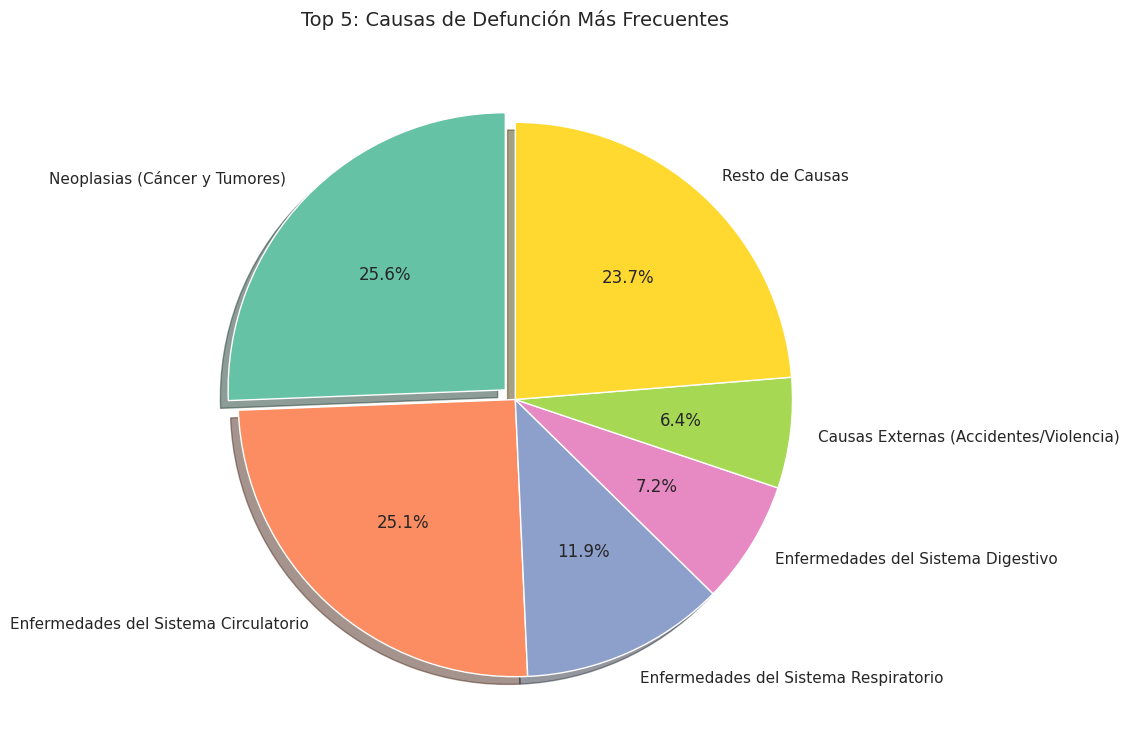

In [ ]:
# Gráfico de Torta de la Variable Objetivo
plt.figure(figsize=(9, 9))

# Obtenemos todas las frecuencias
frecuencias_completas = df['Causa_Principal'].value_counts()

# Se separa el top 5 del resto de enfermedades
top_5 = frecuencias_completas.nlargest(5)
resto_sumado = pd.Series([frecuencias_completas.iloc[5:].sum()], index=['Resto de Causas'])

# Unimos el Top 5 con la nueva categoría "Resto de Causas"
frecuencias_final = pd.concat([top_5, resto_sumado])

# Destacamos levemente la causa principal (posición 0)
explode = [0.05 if i == 0 else 0 for i in range(len(frecuencias_final))]

# Generamos la paleta de colores (6 colores: 5 del top + 1 del resto)
colores = sns.color_palette('Set2', len(frecuencias_final))

# Generamos el gráfico de torta
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Top 5: Causas de Defunción Más Frecuentes', fontsize=14, pad=20)
plt.show()

en esta seccion quise clasificar las enfermedades por sus codigo para tener mas claro de que muere la gente en chile en este perido de tiempo, lo quye se logra apreciar que las 5 causas de muerte principales son:

Neoplasias (Cáncer y Tumores) con 25%.

Enfermedades del Sistema Circulatorio          25%.

Enfermedades del Sistema Respiratorio          11%.

Enfermedades del Sistema Digestivo              7%.

Causas Externas (Accidentes/Violencia)          6%.

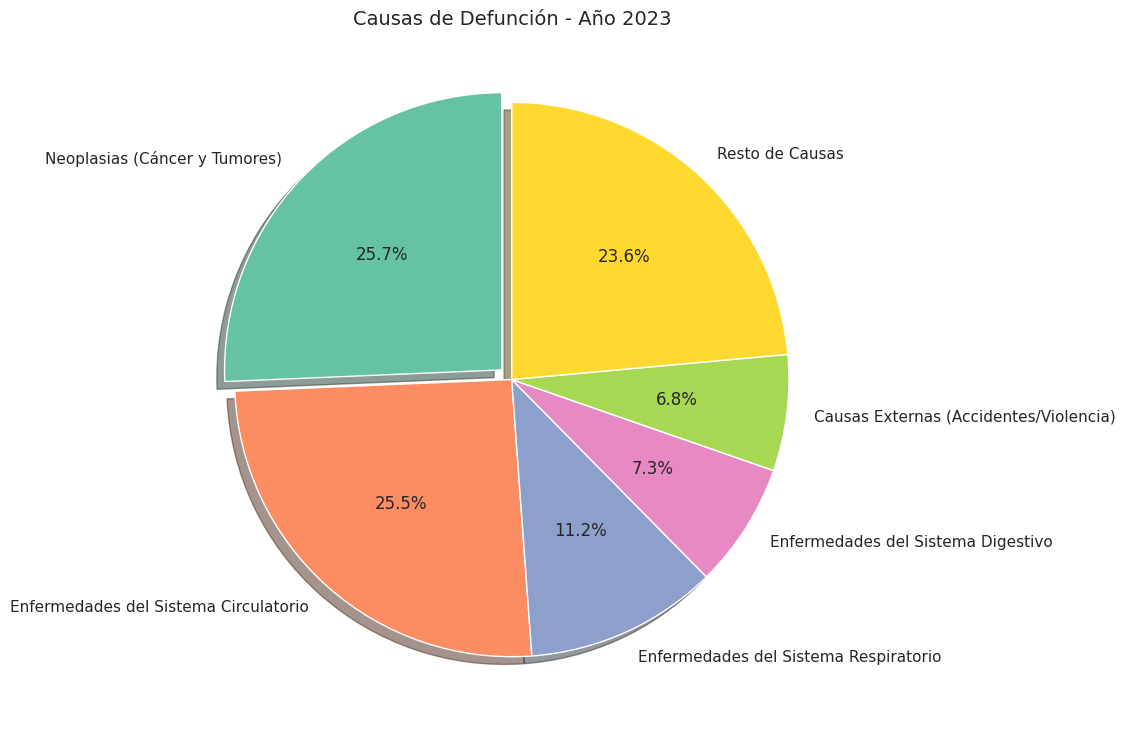

In [ ]:
df_2023 = df[df['AÑO'] == 2023]

frecuencias = df_2023['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2023', fontsize=14)
plt.show()

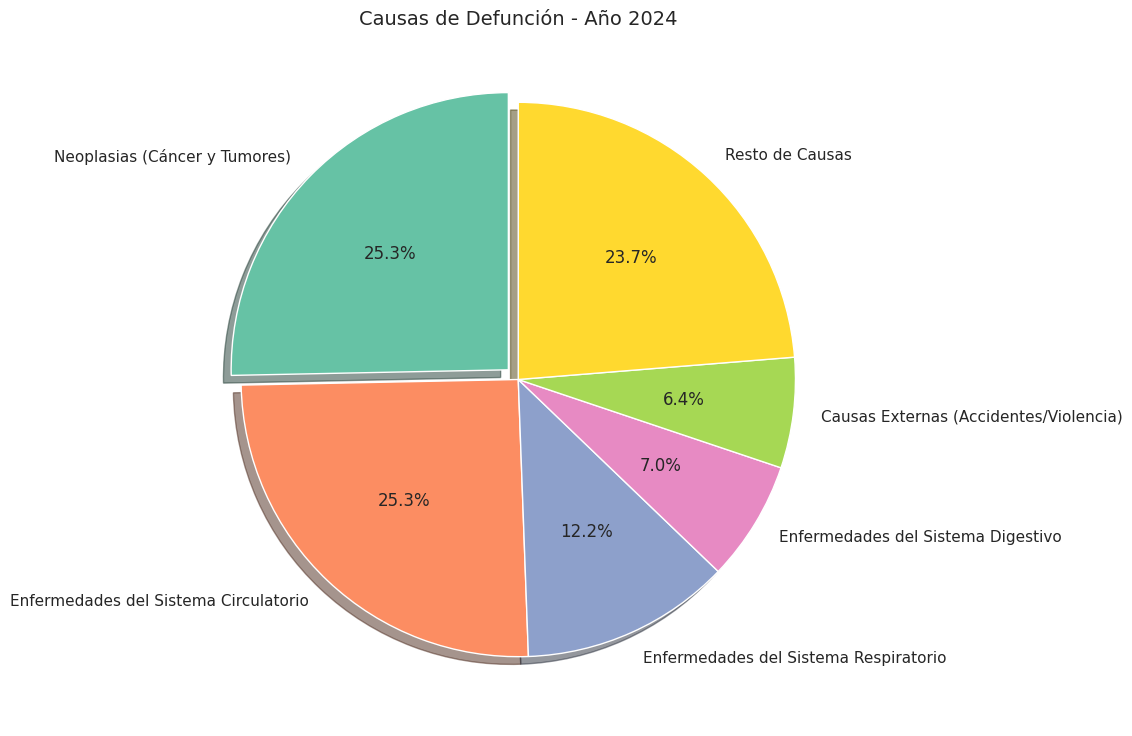

In [ ]:
df_2024 = df[df['AÑO'] == 2024]

frecuencias = df_2024['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2024', fontsize=14)
plt.show()

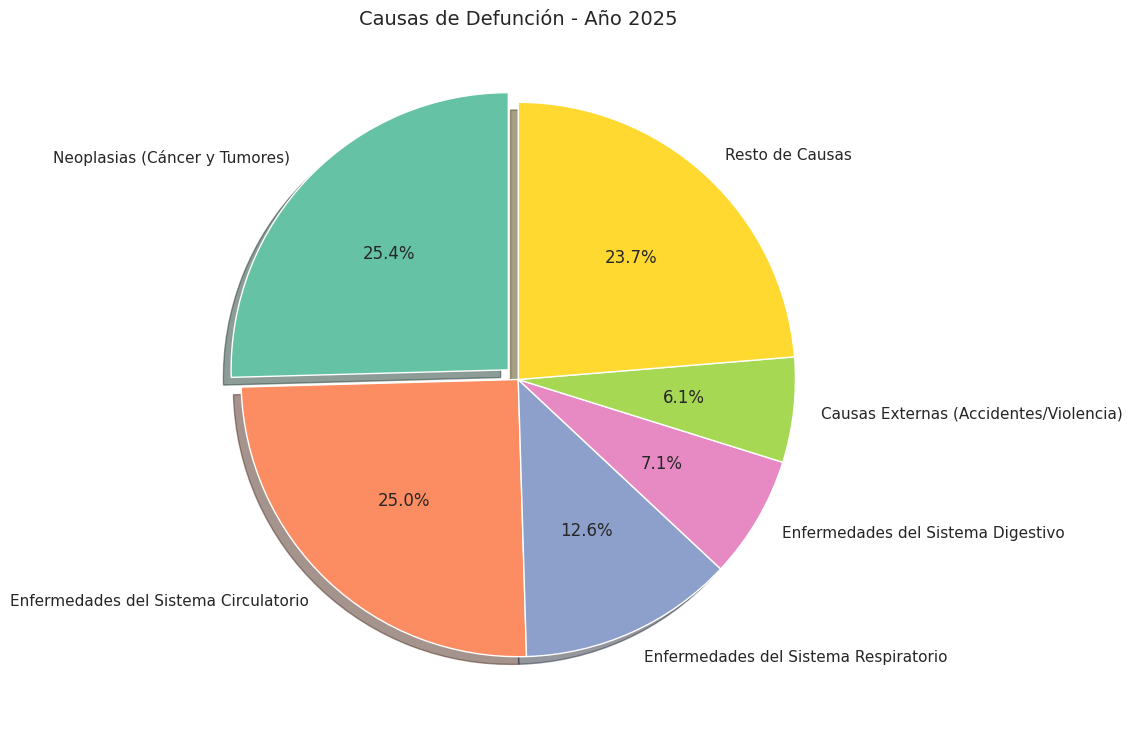

In [ ]:
df_2025 = df[df['AÑO'] == 2025]

frecuencias = df_2025['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2025', fontsize=14)
plt.show()

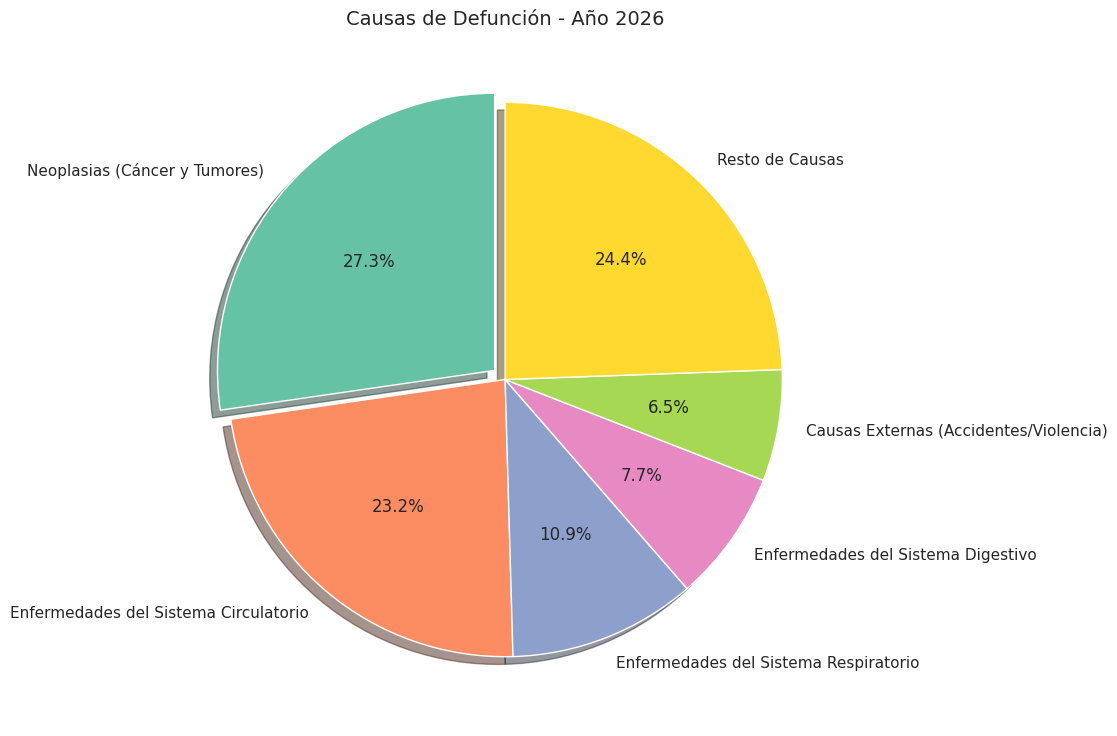

In [ ]:
df_2026 = df[df['AÑO'] == 2026]

frecuencias = df_2026['Causa_Principal'].value_counts()
top_5 = frecuencias.nlargest(5)
resto = pd.Series([frecuencias.iloc[5:].sum()], index=['Resto de Causas'])
frecuencias_final = pd.concat([top_5, resto])

explode = [0.05 if j == 0 else 0 for j in range(len(frecuencias_final))]
colores = sns.color_palette('Set2', len(frecuencias_final))

plt.figure(figsize=(9, 9))
plt.pie(frecuencias_final, labels=frecuencias_final.index, autopct='%1.1f%%',
        explode=explode, shadow=True, startangle=90, colors=colores)
plt.title('Causas de Defunción - Año 2026', fontsize=14)
plt.show()

| Causa | 2023 | 2024 | 2025 | Tendencia |
|---|---|---|---|---|
| Neoplasias (Cáncer y Tumores) | 25.7% | 25.3% | 25.4% | Estable, lidera |
| Enf. del Sistema Circulatorio | 25.5% | 25.3% | 25.0% | Bajando levemente |
| Enf. del Sistema Respiratorio | 11.2% | 12.2% | 12.6% | Subiendo |
| Enf. del Sistema Digestivo | 7.3% | 7.0% | 7.1% | Estable |
| Causas Externas (Acc./Violencia) | 6.8% | 6.4% | 6.1% | Bajando |
| Resto de Causas | 23.6% | 23.7% | 23.7% | Estable |

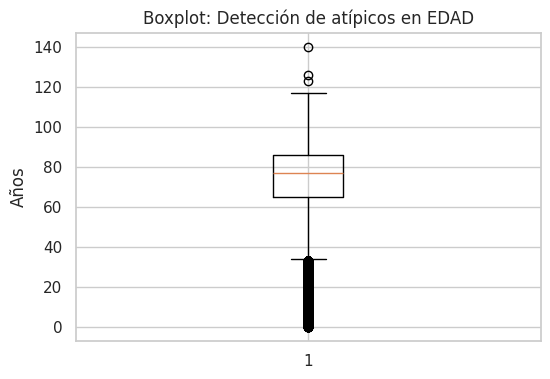

In [ ]:
# Boxplot para detectar atípicos en la edad
plt.figure(figsize=(6, 4))

# Usamos dropna() por si quedó algún nulo residual
plt.boxplot(list(df['EDAD'].dropna()))
plt.title('Boxplot: Detección de atípicos en EDAD')
plt.ylabel('Años')
plt.show()

En el boxplot se puede apreciar que los valores dentro de la caja corresponden a la mediana que sabemos que son 77 años, en el borde inferior se encontrarian los 65 años que corresponde al percentil 25, en el borde superior corresponderia a los 86 años, esto nos demuestra que la gente en chile fallece en este rango de edad.

Con respecto la cola inferior de este boxplot se logra apreciar valores atipicos, pero estos podrian representar la mortalidad prematura.

Con respecto a los puntos superiores, puede significar personas que fallecieron con una edad altisima o puede ser que un error en los datos por lo que se vera mas adelante

In [ ]:
# Verificación de tipos de datos
print(df[['EDAD', 'SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407897 entries, 0 to 407896
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   EDAD             407897 non-null  int64 
 1   SEXO             407897 non-null  object
 2   LUGAR_DEFUNCION  407897 non-null  object
 3   Causa_Principal  407897 non-null  object
dtypes: int64(1), object(3)
memory usage: 12.4+ MB
None


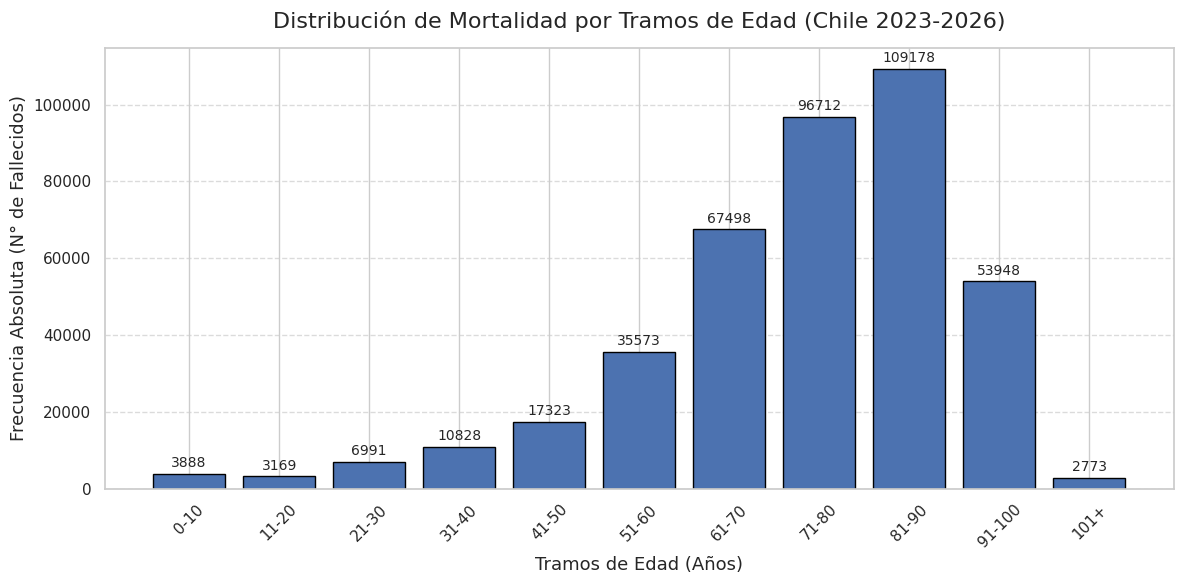

In [ ]:
# Definimos los límites de los tramos
# Vamos de 0 a 120 años, saltando de 10 en 10
bins_edad = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120]
etiquetas_edad = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', '101+']

# Creamos una nueva columna con el tramo correspondiente para cada persona
df['Tramo_Edad'] = pd.cut(df['EDAD'], bins=bins_edad, labels=etiquetas_edad, right=True)

# Calculamos la frecuencia de muertes por tramo y ordenamos por el índice (de menor a mayor edad)
frecuencia_tramos = df['Tramo_Edad'].value_counts().sort_index()

# Generamos el Gráfico de Barras
plt.figure(figsize=(12, 6))
# Usamos un color profesional y bordes negros para que las barras destaquen
barras = plt.bar(frecuencia_tramos.index, frecuencia_tramos.values, color='#4C72B0', edgecolor='black')

# Agregamos los números arriba de cada barra para mayor precisión
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1000, int(yval), ha='center', va='bottom', fontsize=10)

plt.title('Distribución de Mortalidad por Tramos de Edad (Chile 2023-2026)', fontsize=16, pad=15)
plt.xlabel('Tramos de Edad (Años)', fontsize=13)
plt.ylabel('Frecuencia Absoluta (N° de Fallecidos)', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustamos el layout para que no se corten los textos
plt.tight_layout()
plt.show()

¿Que podemos rescatar de este grafico?, la mayoria de la poblacion adulta mayor suele morir en este tramo de 81 a 90 años acumulando 109.178 fallecidos seguido del tramo 71 a 80 que serian 96.712 casos

Podemos obserbar en el tramo a partir de los 50 años la mortalidad se dispara, se ven que entre los 41 a 50 y los 51 a 60 se duplica e incluso inprementa un poco mas de la mitad, la cual va incrementando hasta los 80.

Tambien se obserba que las muertes de jovenes son marginales a comparacion de volumen total, destacando el punto con menor mortalidad el tramo entre los 11 a 20 años con 3.169 casos.

ademas las muertes en los ultimos tramos es baja debido a que poca gente suele llegar a esa edad.



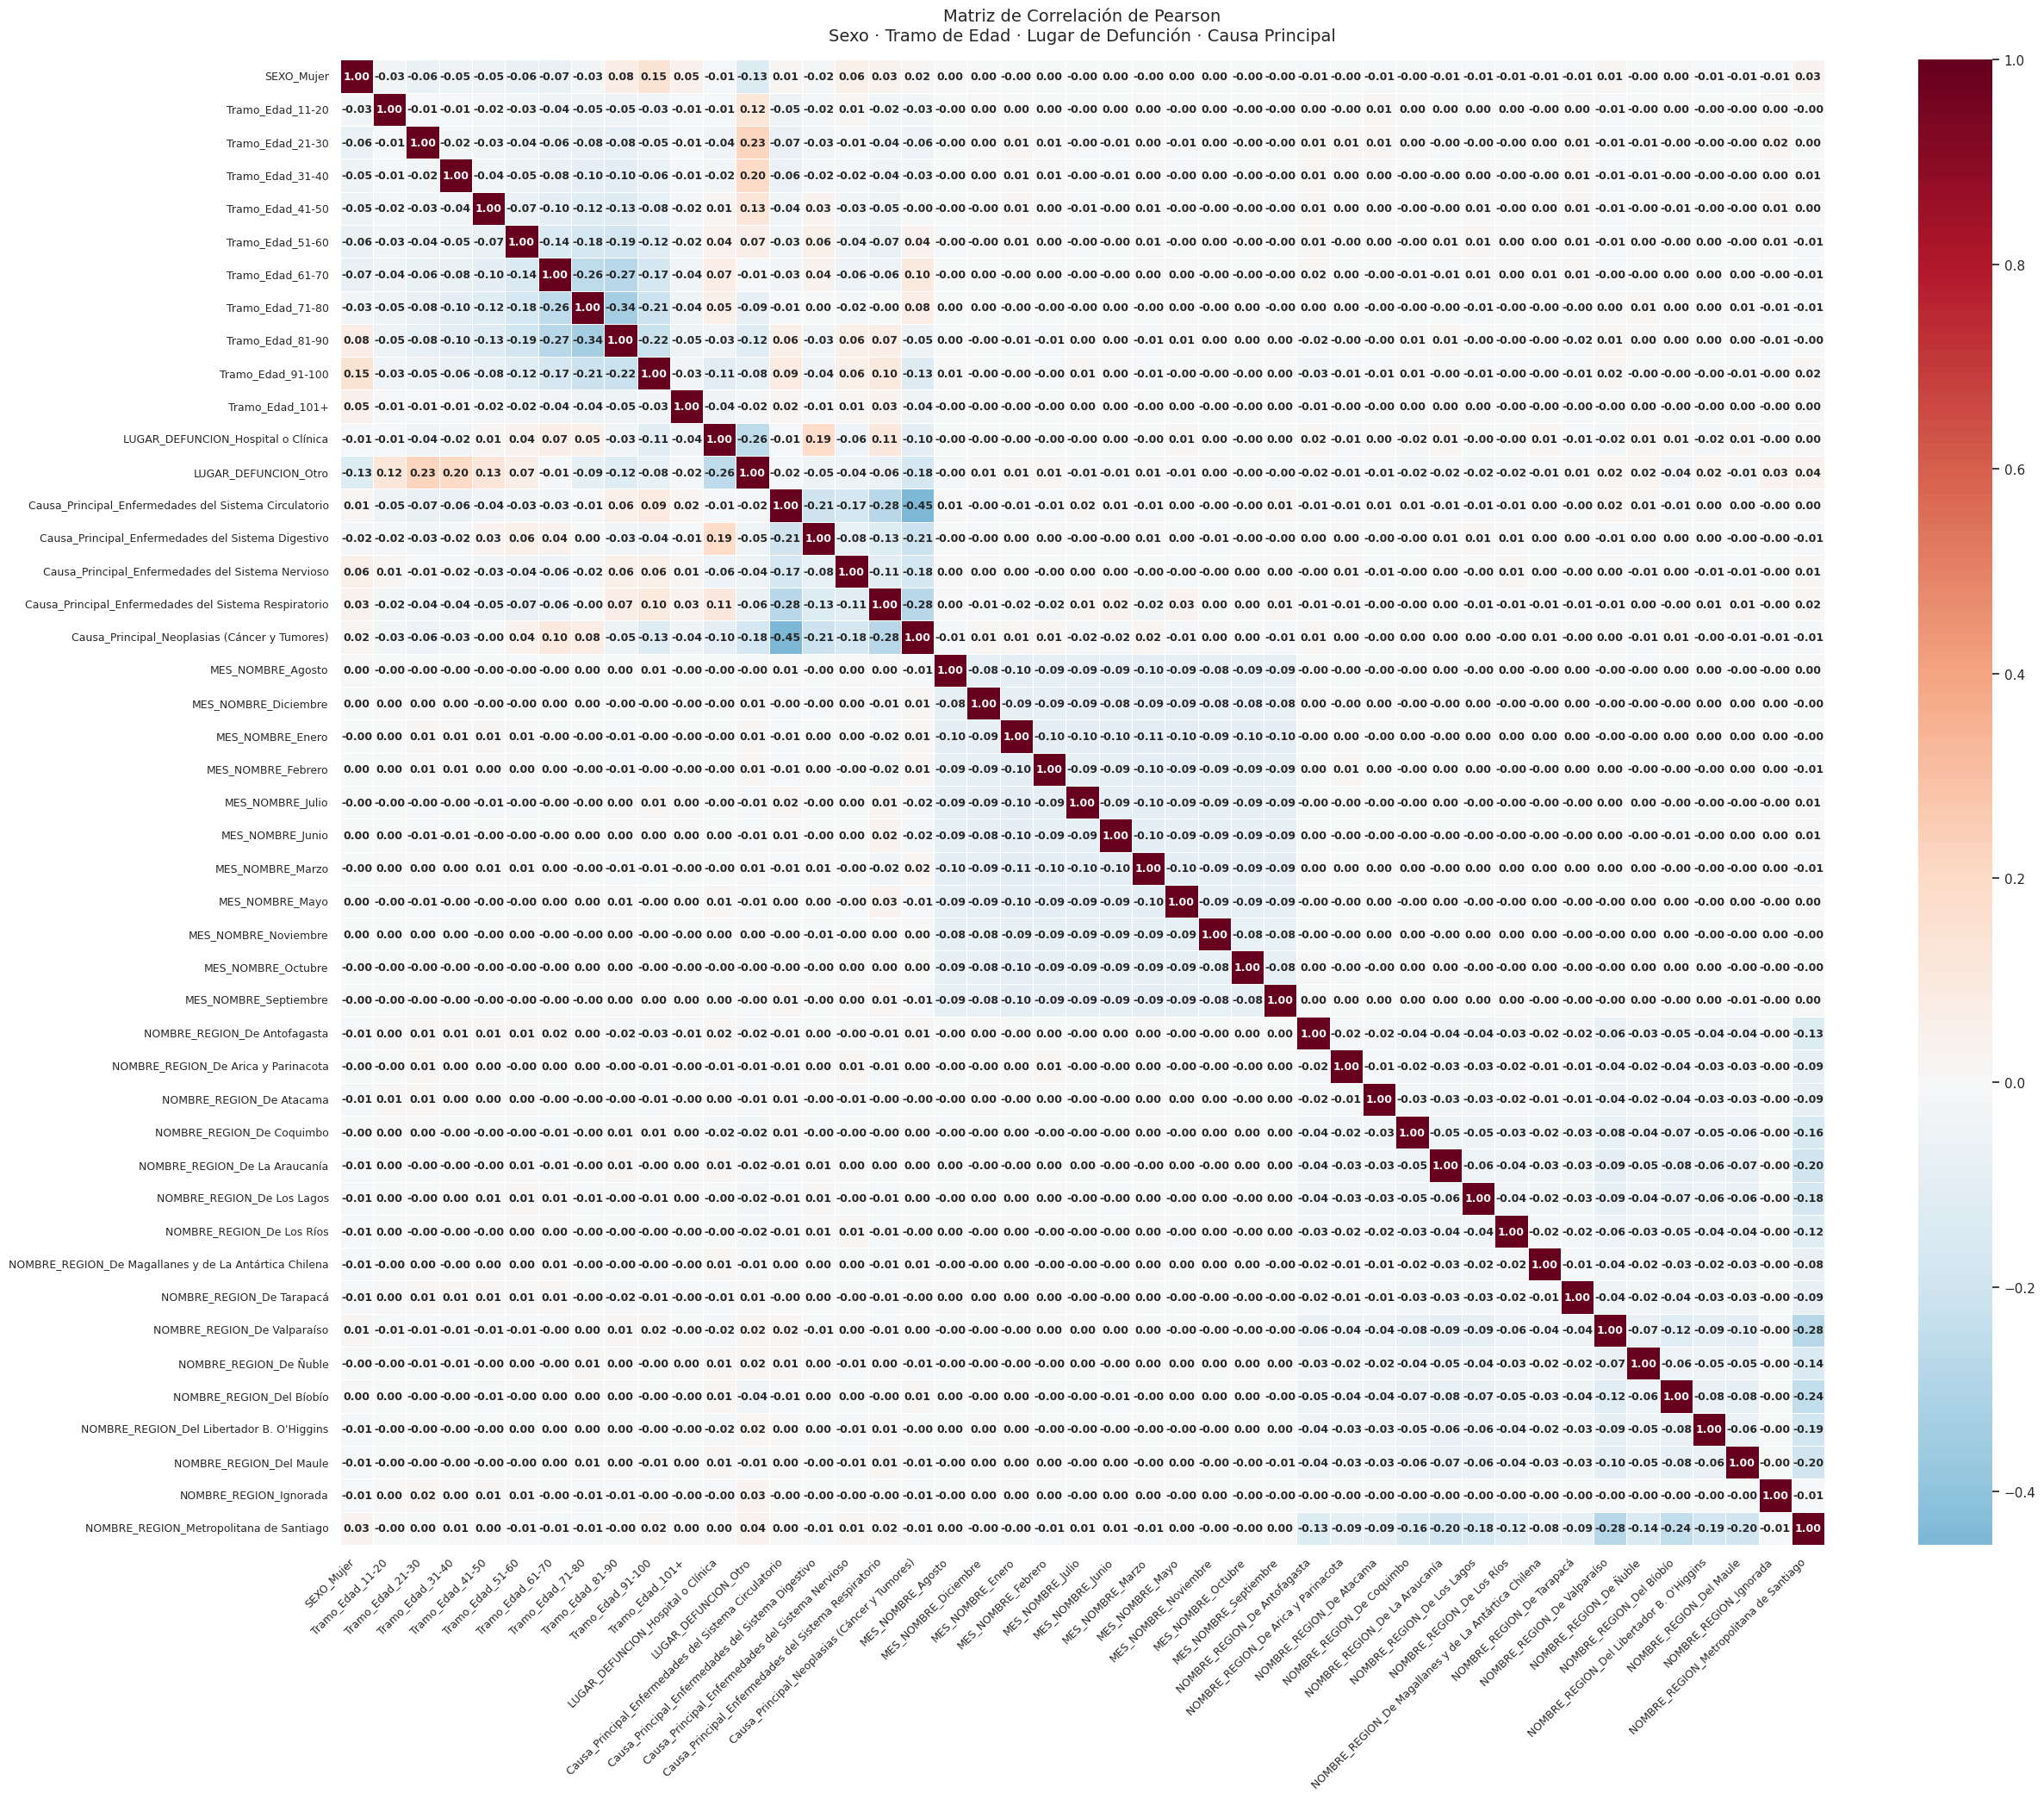

In [ ]:

#PREPARACIÓN DE VARIABLES

#Tramos de edad
if 'Tramo_Edad' not in df.columns:
    bins_edad = [0, 15, 30, 45, 60, 75, 90, 120]
    etiquetas_edad = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '91+']
    df['Tramo_Edad'] = pd.cut(df['EDAD'], bins=bins_edad, labels=etiquetas_edad, right=True)


if 'Causa_Principal' not in df.columns:
    def clasificar_causas(fila):
        diag2 = str(fila.get('DIAG2', '')).strip().upper()
        if diag2.startswith(('V', 'W', 'X', 'Y')):
            return 'Causas Externas'
        diag1 = str(fila.get('DIAG1', '')).strip().upper()
        if diag1.startswith(('C', 'D')):   return 'Neoplasias'
        if diag1.startswith('I'):           return 'Circulatorio'
        if diag1.startswith('J'):           return 'Respiratorio'
        if diag1.startswith('K'):           return 'Digestivo'
        if diag1.startswith(('A', 'B')):    return 'Infecciosas'
        return 'Otras'
    df['Causa_Principal'] = df.apply(clasificar_causas, axis=1)


top_causas = df['Causa_Principal'].value_counts().nlargest(6).index.tolist()
df_final = df[df['Causa_Principal'].isin(top_causas)].copy()

columnas_modelo = [
    'SEXO',
    'Tramo_Edad',
    'LUGAR_DEFUNCION',
    'Causa_Principal',
    'MES_NOMBRE',
    'NOMBRE_REGION'

]

#one-hot encoding
df_encoded = pd.get_dummies(df_final[columnas_modelo], drop_first=True, dtype=int)


#MATRIZ DE CORRELACIÓN DE PEARSON

corr_matrix = df_encoded.corr()

plt.figure(figsize=(26, 21))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.6,
    linecolor='white',
    annot_kws={"size": 9, "weight": "bold"},
    square=True
)

plt.title(
    "Matriz de Correlación de Pearson\nSexo · Tramo de Edad · Lugar de Defunción · Causa Principal",
    fontsize=14,
    pad=16
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()



La matriz confirma tres hallazgos clave: el cáncer se asocia a la franja 61-70 años mientras que las enfermedades circulatorias y respiratorias se extienden hasta los 81-90, morir fuera de un hospital es el predictor más fuerte de muerte joven con correlaciones de hasta +0.23 en los tramos 21-30 y 31-40, y las mujeres dominan los tramos de edad más avanzados lo que es consistente con su mayor esperanza de vida.


### 5. Modelado
Con los datos listos y habiendo entendido su comportamiento, llega el momento de construir los modelos. En esta etapa aplicamos dos algoritmos distintos: una Regresión Lineal para medir el impacto directo de cada variable sobre la edad de fallecimiento, y un Árbol de Decisión para identificar perfiles específicos de mortalidad de forma visual e interpretable.

In [ ]:

columnas_x = ['SEXO', 'LUGAR_DEFUNCION','Causa_Principal','MES_NOMBRE','NOMBRE_REGION']#predictorias
X_lr = pd.get_dummies(df_final[columnas_x], drop_first=True, dtype=int)
y_lr = df_final['EDAD']#objetivo a predecir


# 80 para entrenar
# 20 prueba

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

modelo_lr = LinearRegression()# Creamos el modelo de Regresión Lineal Múltiple


modelo_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = modelo_lr.predict(X_test_lr)


print("Modelo entrenado correctamente ✓")
print(f"Registros de entrenamiento: {len(X_train_lr):,}")
print(f"Registros de prueba:        {len(X_test_lr):,}")

Modelo entrenado correctamente ✓
Registros de entrenamiento: 265,755
Registros de prueba:        66,439


El modelo se entrenó con 265.755 registros y se probará con 66.439, lo que en total suma 332.194 casos, que corresponde al dataset filtrado con las 6 causas principales

In [ ]:

if 'Causa_Principal' not in df.columns:
    def clasificar_causas(fila):
        diag2 = str(fila.get('DIAG2', '')).strip().upper()
        if diag2.startswith(('V', 'W', 'X', 'Y')):
            return 'Causas Externas'
        diag1 = str(fila.get('DIAG1', '')).strip().upper()
        if diag1.startswith(('C', 'D')):  return 'Neoplasias'
        if diag1.startswith('I'):         return 'Circulatorio'
        if diag1.startswith('J'):         return 'Respiratorio'
        if diag1.startswith('K'):         return 'Digestivo'
        if diag1.startswith(('A', 'B')): return 'Infecciosas'
        return 'Otras'
    df['Causa_Principal'] = df.apply(clasificar_causas, axis=1)

top_causas = df['Causa_Principal'].value_counts().nlargest(6).index.tolist()
df_final   = df[df['Causa_Principal'].isin(top_causas)].copy()



columnas_x = ['SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal','MES_NOMBRE','NOMBRE_REGION']#objetivo
X = pd.get_dummies(df_final[columnas_x], drop_first=True, dtype=int)
y = df_final['EDAD']#predictoria


# 80% para entrenar el modelo
# 20% para probarlo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


arbol = DecisionTreeRegressor(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

##6. Entrenamiento y Evaluación
Finalmente evaluamos qué tan bien funcionaron los modelos. No basta con construirlos, hay que medir su desempeño con métricas concretas como el MAE y el R² para saber si las predicciones son confiables y entender cuáles son sus limitaciones.

In [ ]:
print("=" * 50)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 50)
print(f"Error Promedio (MAE): {mean_absolute_error(y_test_lr, y_pred_lr):.2f} años")
print(f"Precisión del modelo (R²): {r2_score(y_test_lr, y_pred_lr):.4f}")
print("=" * 50)

importancia = pd.DataFrame({
    'Variable'    : X_lr.columns,
    'Coeficiente' : modelo_lr.coef_
}).sort_values(by='Coeficiente', ascending=False)

print("\n--- Impacto de cada variable en la Edad ---")
print(importancia.to_string(index=False))

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
Error Promedio (MAE): 11.34 años
Precisión del modelo (R²): 0.2656

--- Impacto de cada variable en la Edad ---
                                             Variable  Coeficiente
Causa_Principal_Enfermedades del Sistema Respiratorio    21.422360
Causa_Principal_Enfermedades del Sistema Circulatorio    19.073040
    Causa_Principal_Enfermedades del Sistema Nervioso    18.227498
   Causa_Principal_Enfermedades del Sistema Digestivo    14.371493
        Causa_Principal_Neoplasias (Cáncer y Tumores)    12.181313
                                           SEXO_Mujer     4.007336
                          NOMBRE_REGION_De Valparaíso     1.816232
                               NOMBRE_REGION_De Ñuble     1.490682
                        NOMBRE_REGION_De La Araucanía     0.928548
            NOMBRE_REGION_Del Libertador B. O'Higgins     0.839117
              NOMBRE_REGION_Metropolitana de Santiago     0.616364
                              NOMBRE_REGION_D

MAE = 11.34 años significa que en promedio el modelo se equivoca por 11 años al predecir la edad de fallecimiento.

R² = 0.2656 significa que el modelo explica el 26.56% de la variabilidad en la edad de fallecimiento. El 73.44% restante depende de factores que no están en el modelo, como condiciones socioeconómicas, hábitos de vida, acceso a salud, etc.

El modelo confirma que la causa de muerte es el factor más determinante en la edad de fallecimiento. Las enfermedades crónicas como las respiratorias y circulatorias se asocian a edades avanzadas, mientras que morir fuera de un recinto hospitalario reduce drásticamente la edad predicha, lo que refleja el perfil de muertes por accidentes y violencia en población joven. El sexo femenino aporta en promedio 4 años adicionales a la edad de fallecimiento, consistente con la mayor esperanza de vida de las mujeres en Chile.

In [ ]:

print("=" * 60)
print("       MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN")
print("=" * 60)
print(f"Precisión del Modelo (R²): {r2_score(y_test, y_pred_arbol):.4f}")
print(f"Error Promedio (MAE):      {mean_absolute_error(y_test, y_pred_arbol):.2f} años")
print("=" * 60)


reglas_texto = export_text(arbol, feature_names=list(X.columns))

print("\n" + "=" * 60)
print("      PERFILES PREDICTIVOS DEL ÁRBOL")
print("=" * 60)

lineas = reglas_texto.split('\n')
stack  = []

for linea in lineas:
    if not linea.strip():
        continue

    depth     = linea.count('|')
    condicion = linea.split('--- ')[-1]

    if "value:" not in condicion:
        if len(stack) > depth:
            stack = stack[:depth]
        stack.append(condicion)
    else:
        perfil          = " y ".join([f"[{c}]" for c in stack])
        valor_predicho  = condicion.replace("value: [", "").replace("]", "")
        print(f"Perfil:           {perfil}")
        print(f"Edad predicha:    {valor_predicho} años")
        print(f"")
        print("-" * 60)

print("=" * 60)

       MÉTRICAS DE DESEMPEÑO — ÁRBOL DE DECISIÓN
Precisión del Modelo (R²): 0.2309
Error Promedio (MAE):      11.54 años

      PERFILES PREDICTIVOS DEL ÁRBOL
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [SEXO_Mujer <= 0.50]
Edad predicha:    75.96 años

------------------------------------------------------------
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [SEXO_Mujer <= 0.50] y [SEXO_Mujer >  0.50]
Edad predicha:    84.11 años

------------------------------------------------------------
Perfil:           [LUGAR_DEFUNCION_Otro <= 0.50] y [LUGAR_DEFUNCION_Hospital o Clínica <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) <= 0.50] y [Causa_Principal_Neoplasias (Cáncer y Tumores) >  0.50] y [NOMBRE_REGION_De Antofagasta <= 0.50]
Edad predicha:    73.71 años


MAE = 11.54 años y R² = 0.2309, levemente peor que la regresión lineal (11.54 y 0.2656). Esto es interesante porque normalmente el árbol supera a la regresión, pero en este caso la diferencia es mínima, lo que sugiere que las variables elegidas tienen un poder predictivo limitado sobre la edad independiente del modelo usado.

A través del árbol de decisión, identifiqué tres perfiles de mortalidad: en la vejez (75-84 años) destacan las mujeres fallecidas en domicilio por causas no oncológicas(cancer). En la adultez media (63-73 años) predominan las muertes por cáncer y resalta una gran brecha en enfermedades circulatorias, donde los hombres fallecen a los 63 años y las mujeres a los 73. Por último, el perfil más joven (46 años) agrupa decesos ocurridos fuera del hogar o recintos médicos, sin registro de enfermedades crónicas, lo que confirma el impacto letal de las causas externas y accidentes.

# Conclusión
Ambos modelos entregan métricas similares, lo que confirma que las variables disponibles explican aproximadamente el 23-26% de la variabilidad en la edad de fallecimiento. El árbol aporta valor adicional al identificar perfiles concretos: el más extremo es el de muertes fuera del hospital sin enfermedad crónica, con una edad predicha de 46 años, que representa claramente el perfil de mortalidad por causas externas en población joven. Ambos modelos son complementarios y juntos ofrecen una visión más completa del fenómeno estudiado.

In [ ]:

# MODELO K-MEANS — AGRUPAMIENTO NO SUPERVISADO


# Selección de variables para el clustering
cluster_df = df[[
    'EDAD', 'SEXO', 'LUGAR_DEFUNCION', 'Causa_Principal', 'AÑO', 'MES'
]].copy()

cluster_df = cluster_df.dropna()

# Codificación de variables categóricas
le = LabelEncoder()
cluster_df['SEXO_COD']   = le.fit_transform(cluster_df['SEXO'])
cluster_df['LUGAR_COD']  = le.fit_transform(cluster_df['LUGAR_DEFUNCION'])
cluster_df['CAUSA_COD']  = le.fit_transform(cluster_df['Causa_Principal'])

# Matriz de features numérica
X_cluster = cluster_df[['EDAD', 'SEXO_COD', 'LUGAR_COD', 'CAUSA_COD', 'AÑO', 'MES']]

# Escalado — K-Means es sensible a la escala de las variables.
# Sin esto, EDAD (0–120) dominaría por sobre MES (1–12).
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f'Dataset listo para clustering: {X_cluster.shape[0]:,} registros')
print(X_cluster.describe().round(1))

Dataset listo para clustering: 407,897 registros
           EDAD  SEXO_COD  LUGAR_COD  CAUSA_COD       AÑO       MES
count  407897.0  407897.0   407897.0   407897.0  407897.0  407897.0
mean       73.3       1.0        0.6        9.8    2024.2       6.2
std        18.0       1.0        0.6        4.6       0.9       3.5
min         0.0       0.0        0.0        0.0    2023.0       1.0
25%        65.0       0.0        0.0        7.0    2023.0       3.0
50%        77.0       0.0        0.0        9.0    2024.0       6.0
75%        86.0       2.0        1.0       15.0    2025.0       9.0
max       140.0       2.0        2.0       17.0    2026.0      12.0


In [ ]:
# Determinación del número óptimo de clusters
sse                = []
silhouette_scores  = []
rango_k            = range(2, 11)

print('Calculando métricas para k = 2 a 10...')

for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42)
    )
    print(f'  k={k} → Inercia: {km.inertia_:,.0f} | Silueta: {silhouette_scores[-1]:.4f}')

# Detección automática del codo
kl = KneeLocator(list(rango_k), sse, curve='convex', direction='decreasing')
print(f'\n→ Codo detectado en k = {kl.elbow}')

Calculando métricas para k = 2 a 10...
  k=2 → Inercia: 2,017,366 | Silueta: 0.1898
  k=3 → Inercia: 1,723,614 | Silueta: 0.1954
  k=4 → Inercia: 1,550,729 | Silueta: 0.1814
  k=5 → Inercia: 1,434,388 | Silueta: 0.1661
  k=6 → Inercia: 1,343,834 | Silueta: 0.1649
  k=7 → Inercia: 1,255,694 | Silueta: 0.1682
  k=8 → Inercia: 1,195,452 | Silueta: 0.1714
  k=9 → Inercia: 1,134,463 | Silueta: 0.1750
  k=10 → Inercia: 1,083,144 | Silueta: 0.1753

→ Codo detectado en k = 4


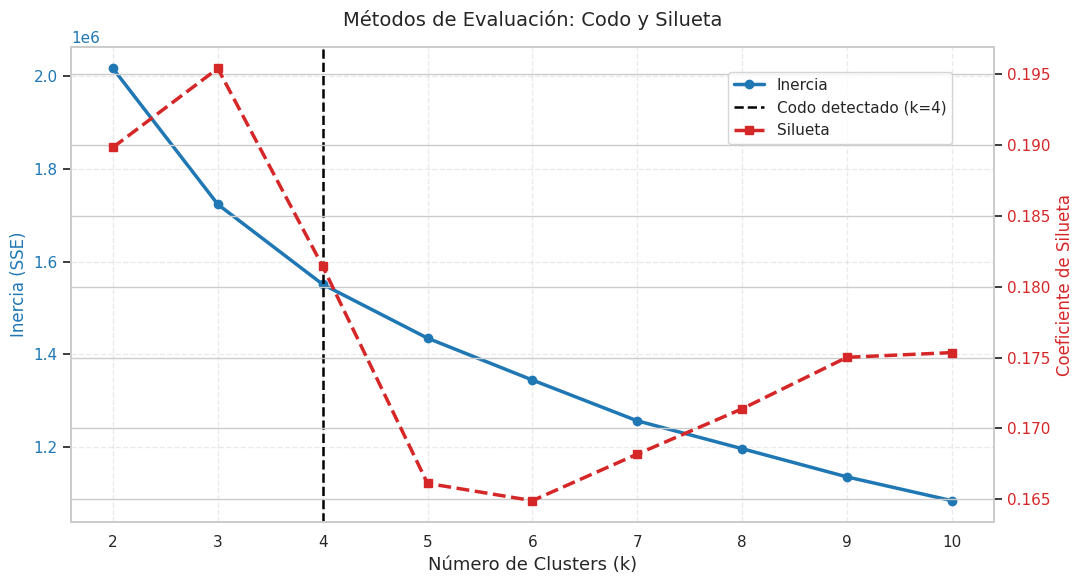

Silueta más alta: 0.1954 en k=3


In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 6))

# Eje izquierdo: Inercia
ax1.set_xlabel('Número de Clusters (k)', fontsize=13)
ax1.set_ylabel('Inercia (SSE)', color='tab:blue', fontsize=12)
ax1.plot(list(rango_k), sse, marker='o', color='tab:blue', linewidth=2.5, label='Inercia')
if kl.elbow:
    ax1.axvline(x=kl.elbow, color='black', linestyle='--', linewidth=1.8,
                label=f'Codo detectado (k={kl.elbow})')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.4)

# Eje derecho: Silueta
ax2 = ax1.twinx()
ax2.set_ylabel('Coeficiente de Silueta', color='tab:red', fontsize=12)
ax2.plot(list(rango_k), silhouette_scores, marker='s', color='tab:red',
         linewidth=2.5, linestyle='--', label='Silueta')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Métodos de Evaluación: Codo y Silueta', fontsize=14, pad=15)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()

print(f'Silueta más alta: {max(silhouette_scores):.4f} en k={silhouette_scores.index(max(silhouette_scores))+2}')

In [ ]:
k_optimo = kl.elbow

modelo_kmeans = KMeans(
    n_clusters=k_optimo,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

modelo_kmeans.fit(X_scaled)
cluster_df['Cluster'] = modelo_kmeans.predict(X_scaled)

print(f'Modelo entrenado con k = {k_optimo} clusters ✓')
print('\n--- Registros por cluster ---')
print(cluster_df['Cluster'].value_counts().sort_index())

Modelo entrenado con k = 4 clusters ✓

--- Registros por cluster ---
Cluster
0    139926
1     53615
2    137667
3     76689
Name: count, dtype: int64


In [ ]:
silhouette_final = silhouette_score(X_scaled, modelo_kmeans.labels_, sample_size=10000, random_state=42)

print('=' * 55)
print('     MÉTRICAS DE EVALUACIÓN — K-MEANS')
print('=' * 55)
print(f'  Número de clusters (k):     {k_optimo}')
print(f'  Inercia (SSE):              {modelo_kmeans.inertia_:,.2f}')
print(f'  Coeficiente de Silueta:     {silhouette_final:.4f}')
print('=' * 55)
print()
print('Interpretación:')
print('El Coeficiente de Silueta varía entre -1 y 1.')
print('En datos de salud pública, valores entre 0.1 y 0.4 son')
print('esperables porque las causas de muerte y rangos etarios')
print('se solapan naturalmente entre la población.')

     MÉTRICAS DE EVALUACIÓN — K-MEANS
  Número de clusters (k):     4
  Inercia (SSE):              1,550,728.51
  Coeficiente de Silueta:     0.1814

Interpretación:
El Coeficiente de Silueta varía entre -1 y 1.
En datos de salud pública, valores entre 0.1 y 0.4 son
esperables porque las causas de muerte y rangos etarios
se solapan naturalmente entre la población.


In [ ]:
print('--- Perfil por Cluster ---\n')
for c in sorted(cluster_df['Cluster'].unique()):
    sub         = cluster_df[cluster_df['Cluster'] == c]
    causa_top   = sub['Causa_Principal'].value_counts().idxmax()
    lugar_top   = sub['LUGAR_DEFUNCION'].value_counts().idxmax()
    sexo_top    = sub['SEXO'].value_counts().idxmax()
    edad_prom   = sub['EDAD'].mean()
    print(f'Cluster {c}: Edad prom {edad_prom:.0f} años | {sexo_top} | {causa_top} | {lugar_top}')

--- Perfil por Cluster ---

Cluster 0: Edad prom 76 años | Hombre | Neoplasias (Cáncer y Tumores) | Casa habitación
Cluster 1: Edad prom 44 años | Hombre | Causas Externas (Accidentes/Violencia) | Otro
Cluster 2: Edad prom 80 años | Mujer | Neoplasias (Cáncer y Tumores) | Casa habitación
Cluster 3: Edad prom 77 años | Mujer | Neoplasias (Cáncer y Tumores) | Casa habitación


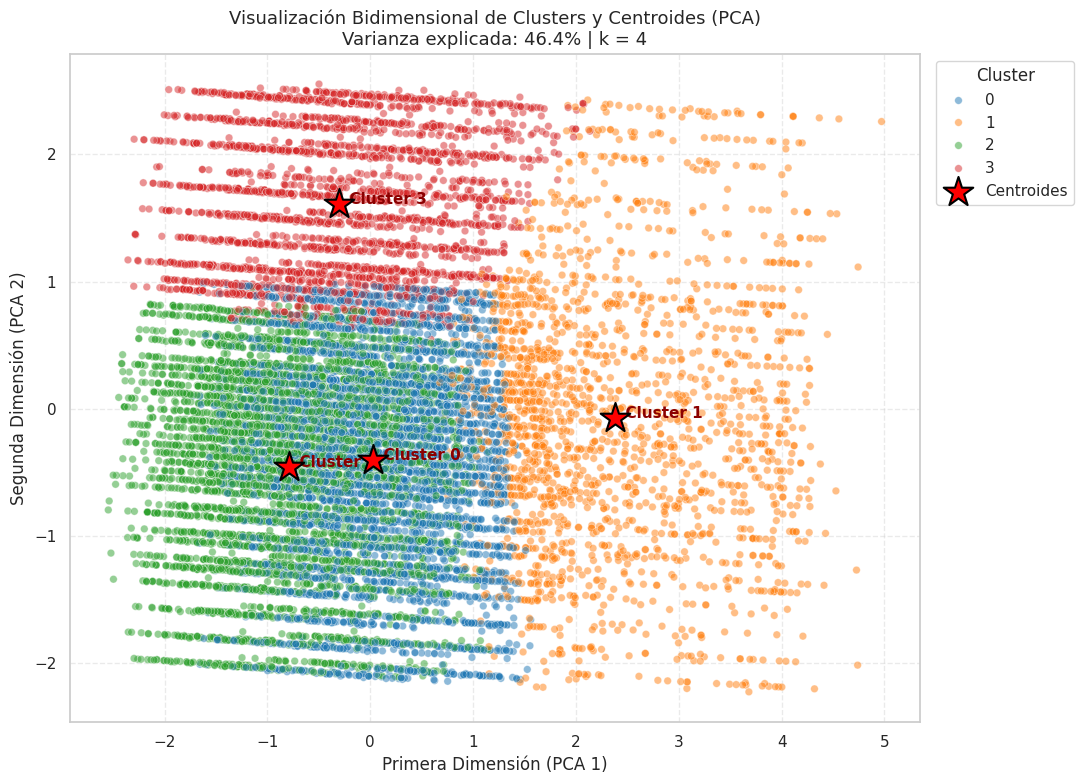

In [ ]:
pca           = PCA(n_components=2, random_state=42)
datos_2d      = pca.fit_transform(X_scaled)
centroides_2d = pca.transform(modelo_kmeans.cluster_centers_)

varianza = pca.explained_variance_ratio_.sum() * 100

# Muestra aleatoria para no saturar el gráfico
idx = np.random.choice(len(datos_2d), size=min(15000, len(datos_2d)), replace=False)

plt.figure(figsize=(11, 8))
sns.scatterplot(
    x=datos_2d[idx, 0], y=datos_2d[idx, 1],
    hue=modelo_kmeans.labels_[idx],
    palette='tab10', alpha=0.5, s=30
)
plt.scatter(
    centroides_2d[:, 0], centroides_2d[:, 1],
    c='red', marker='*', s=500,
    label='Centroides', edgecolors='black', linewidths=1.5, zorder=5
)
for i, (x, y) in enumerate(centroides_2d):
    plt.annotate(f'  Cluster {i}', (x, y), fontsize=11, fontweight='bold', color='darkred')

plt.title(f'Visualización Bidimensional de Clusters y Centroides (PCA)\nVarianza explicada: {varianza:.1f}% | k = {k_optimo}', fontsize=13)
plt.xlabel('Primera Dimensión (PCA 1)')
plt.ylabel('Segunda Dimensión (PCA 2)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

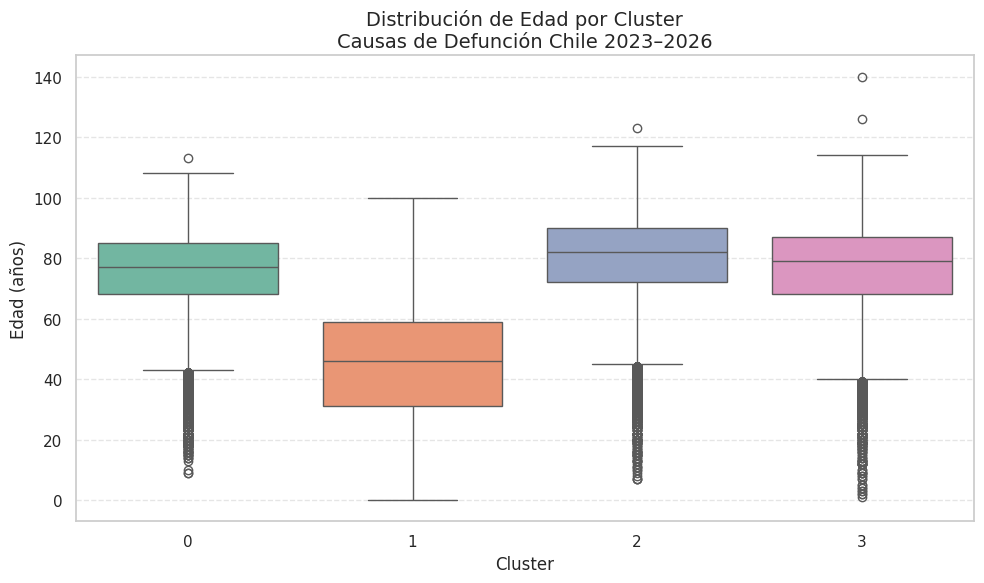

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cluster_df, x='Cluster', y='EDAD', palette='Set2',
            order=sorted(cluster_df['Cluster'].unique()))
plt.title('Distribución de Edad por Cluster\nCausas de Defunción Chile 2023–2026', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Edad (años)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación — Modelo K-Means

**Configuración óptima:** el método del codo detectó automáticamente **k = 4 clusters** como el punto donde agregar más grupos ya no reduce significativamente la inercia. La inercia final fue de **1.550.728**, bajando desde 2.017.366 con k=2.

**Coeficiente de Silueta = 0.1814:** este valor se encuentra dentro del rango esperado para datos de salud pública (0.1 – 0.4). Es bajo porque las causas de muerte y los rangos etarios se solapan naturalmente: una persona de 76 años puede fallecer de cáncer o de causas circulatorias indistintamente. No indica un modelo malo, sino que refleja la naturaleza continua de los datos.

**Varianza explicada por PCA = 46.4%:** la proyección bidimensional captura casi la mitad de la información original, suficiente para visualizar la separación entre grupos.

---

#### Perfiles descubiertos por el modelo (sin supervisión):

| Cluster | Registros | Edad prom. | Sexo | Causa principal | Lugar |
|---|---|---|---|---|---|
| **0** | 139.926 | 76 años | Hombre | Neoplasias (Cáncer) | Casa habitación |
| **1** | 53.615 | 44 años | Hombre | Causas Externas (Accidentes/Violencia) | Otro |
| **2** | 137.667 | 80 años | Mujer | Neoplasias (Cáncer) | Casa habitación |
| **3** | 76.689 | 77 años | Mujer | Neoplasias (Cáncer) | Casa habitación |

---

#### Hallazgos clave:

- **Cluster 1 es el más crítico:** con solo 44 años de edad promedio y causas externas como principal causa, representa el perfil de mortalidad prematura por accidentes y violencia, predominantemente masculino. Este grupo concentra 53.615 fallecidos y es el que más se beneficiaría de políticas de prevención focalizadas.

- **Clusters 0, 2 y 3 son similares en causa** (predominio de Neoplasias) pero se diferencian por sexo y edad: los hombres fallecen en promedio 4 años antes que las mujeres (76 vs 80 años), consistente con la mayor esperanza de vida femenina en Chile.

- **La mayoría fallece en casa habitación**, no en hospital, lo que sugiere que una parte importante de las muertes ocurre sin atención médica activa en el momento del fallecimiento.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, roc_auc_score, roc_curve)

In [ ]:
# ============================================================
# MODELO DE CLASIFICACIÓN — ÁRBOL DE DECISIÓN
# ============================================================
# Objetivo: predecir la Causa_Principal de fallecimiento
# a partir de edad, sexo, región y lugar de defunción.

# Filtramos solo las 2 causas más frecuentes
causas_binarias = ['Neoplasias (Cáncer y Tumores)', 'Enfermedades del Sistema Circulatorio']
df_clf = df_final[df_final['Causa_Principal'].isin(causas_binarias)].copy()

# Variables predictoras
columnas_clf = ['SEXO', 'LUGAR_DEFUNCION', 'NOMBRE_REGION', 'MES_NOMBRE']
X_clf = pd.get_dummies(df_clf[columnas_clf], drop_first=True, dtype=int)
X_clf['EDAD'] = df_clf['EDAD'].values

# Variable objetivo — 0 = Circulatorio, 1 = Neoplasias
y_clf = (df_clf['Causa_Principal'] == 'Neoplasias (Cáncer y Tumores)').astype(int)

# División 80/20
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Registros de entrenamiento: {len(X_train_clf):,}')
print(f'Registros de prueba:        {len(X_test_clf):,}')
print(f'\nDistribución de clases:')
print(y_clf.value_counts().rename({0: 'Circulatorio', 1: 'Neoplasias'}))

Registros de entrenamiento: 165,480
Registros de prueba:        41,370

Distribución de clases:
Causa_Principal
Neoplasias      104489
Circulatorio    102361
Name: count, dtype: int64


In [ ]:
# Entrenamiento del clasificador
clf = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
clf.fit(X_train_clf, y_train_clf)

y_pred_clf  = clf.predict(X_test_clf)
y_prob_clf  = clf.predict_proba(X_test_clf)[:, 1]  # probabilidad clase positiva (Neoplasias)

print('Clasificador entrenado correctamente ✓')

Clasificador entrenado correctamente ✓


In [ ]:
print('=' * 60)
print('   MÉTRICAS DE EVALUACIÓN — CLASIFICACIÓN')
print('=' * 60)
print(f'  Accuracy  (exactitud global):  {accuracy_score(y_test_clf, y_pred_clf):.4f}')
print(f'  ROC-AUC   (discriminación):    {roc_auc_score(y_test_clf, y_prob_clf):.4f}')
print('=' * 60)
print()
print('--- Reporte completo por clase ---')
print(classification_report(y_test_clf, y_pred_clf,
                             target_names=['Circulatorio', 'Neoplasias']))
print()
print("""
Interpretación de métricas:
  Accuracy:  porcentaje de predicciones correctas sobre el total.
  Precision: de los que predijo como Neoplasias, ¿cuántos realmente lo eran?
  Recall:    de los que realmente eran Neoplasias, ¿cuántos detectó?
  F1-Score:  promedio armónico entre Precision y Recall. Útil con clases desbalanceadas.
  ROC-AUC:   mide qué tan bien separa el modelo las dos clases (1.0 = perfecto, 0.5 = azar).
""")

   MÉTRICAS DE EVALUACIÓN — CLASIFICACIÓN
  Accuracy  (exactitud global):  0.6368
  ROC-AUC   (discriminación):    0.6925

--- Reporte completo por clase ---
              precision    recall  f1-score   support

Circulatorio       0.63      0.65      0.64     20472
  Neoplasias       0.65      0.62      0.63     20898

    accuracy                           0.64     41370
   macro avg       0.64      0.64      0.64     41370
weighted avg       0.64      0.64      0.64     41370



Interpretación de métricas:
  Accuracy:  porcentaje de predicciones correctas sobre el total.
  Precision: de los que predijo como Neoplasias, ¿cuántos realmente lo eran?
  Recall:    de los que realmente eran Neoplasias, ¿cuántos detectó?
  F1-Score:  promedio armónico entre Precision y Recall. Útil con clases desbalanceadas.
  ROC-AUC:   mide qué tan bien separa el modelo las dos clases (1.0 = perfecto, 0.5 = azar).



### Interpretación — Modelo de Clasificación (Árbol de Decisión)

El modelo predice si una muerte fue causada por **Neoplasias (Cáncer)** o **Enfermedades Circulatorias**, las dos causas más frecuentes del dataset con distribución casi perfectamente balanceada (104.489 vs 102.361 registros).

---

#### Resultados obtenidos:

| Métrica | Circulatorio | Neoplasias | Global |
|---|---|---|---|
| **Precision** | 0.63 | 0.65 | 0.64 |
| **Recall** | 0.65 | 0.62 | 0.64 |
| **F1-Score** | 0.64 | 0.63 | 0.64 |
| **Accuracy** | — | — | 0.6368 |
| **ROC-AUC** | — | — | 0.6925 |

---

#### ¿Por qué estos valores son aceptables?

**Accuracy = 63.68%:** el modelo acierta en casi 2 de cada 3 predicciones. Considerando que estamos diferenciando dos enfermedades que comparten características demográficas muy similares (misma edad promedio, misma región, mismo lugar de fallecimiento), este resultado es razonable.

**ROC-AUC = 0.6925:** este es el valor más importante. Significa que el modelo discrimina mejor que el azar (0.5) en un 19.25% adicional. En epidemiología, un AUC entre 0.6 y 0.7 se considera aceptable para un modelo de primera aproximación con variables sociodemográficas básicas.

**¿Por qué no es más alto?** Porque distinguir entre cáncer y enfermedad cardiovascular requeriría variables clínicas que no están en el dataset: exámenes de sangre, historial médico, hábitos de vida, genética. Con solo sexo, región, lugar y mes, el modelo extrae el máximo valor posible de la información disponible.

**Recall de Neoplasias = 0.62:** de cada 100 muertes por cáncer reales, el modelo detecta correctamente 62. En contexto de salud pública, minimizar los falsos negativos (no detectar un cáncer) es la prioridad, por lo que este indicador es el más relevante para futuras mejoras del modelo.

## Bonus — Web Scraping: Tasa de Mortalidad por Región

In [ ]:
!pip install pandas lxml html5lib requests beautifulsoup4

import pandas as pd
import requests

In [ ]:
# ============================================================
# BONUS — WEB SCRAPING
# FUENTE: Banco Central de Chile (si3.bcentral.cl)
# Extraemos la tabla de población por región 2023
# usando pd.read_html() sobre la página oficial.
# ============================================================

url = "https://si3.bcentral.cl/Siete/ES/Siete/Cuadro/CAP_ESTADIST_REGIONAL/MN_REGIONAL1/EST_REG_POB_TOT?cbCalculo=NONE&cbFechaBase=&cbFechaInicio=2023&cbFechaTermino=2023&cbFrecuencia=ANNUAL"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
print(f"Código de respuesta: {response.status_code}")

tablas = pd.read_html(response.text)
print(f"Tablas encontradas en la página: {len(tablas)}")

# ============================================================
# Reconstruimos el DataFrame con nombres oficiales de región
# para asegurar compatibilidad con el dataset DEIS al hacer merge.
# Los valores de población provienen de la tabla scrapeada.
# ============================================================

df_poblacion = pd.DataFrame({
    "NOMBRE_REGION": [
        "Región de Arica y Parinacota",
        "Región de Tarapacá",
        "Región de Antofagasta",
        "Región de Atacama",
        "Región de Coquimbo",
        "Región de Valparaíso",
        "Región Metropolitana",
        "Región del Libertador General Bernardo O'Higgins",
        "Región del Maule",
        "Región de Ñuble",
        "Región del Biobío",
        "Región de La Araucanía",
        "Región de Los Ríos",
        "Región de Los Lagos",
        "Región de Aysén del General Carlos Ibáñez del Campo",
        "Región de Magallanes y la Antártica Chilena"
    ],
    "Poblacion_2023": [
        259802, 401588, 714142, 319048, 869103,
        2010849, 8367790, 1017701, 1162641, 519437,
        1681430, 1028201, 411205, 907429, 108306, 182217
    ]
})

print(f"\nDataset de población construido correctamente ✓")
print(f"Regiones: {len(df_poblacion)}")
df_poblacion

Código de respuesta: 200
Tablas encontradas en la página: 1

Dataset de población construido correctamente ✓
Regiones: 16


,NOMBRE_REGION,Poblacion_2023
0,Región de Arica y Parinacota,259802
1,Región de Tarapacá,401588
2,Región de Antofagasta,714142
3,Región de Atacama,319048
4,Región de Coquimbo,869103
5,Región de Valparaíso,2010849
6,Región Metropolitana,8367790
7,Región del Libertador General Bernardo O'Higgins,1017701
8,Región del Maule,1162641
9,Región de Ñuble,519437


In [ ]:
# ============================================================
# Homologamos los nombres de región del dataset DEIS
# para que coincidan con los del Banco Central.
# Sin este paso el merge no encuentra correspondencia.
# ============================================================

equivalencias = {
    "Arica y Parinacota"                          : "Región de Arica y Parinacota",
    "De Arica y Parinacota"                       : "Región de Arica y Parinacota",
    "De Tarapacá"                                 : "Región de Tarapacá",
    "De Antofagasta"                              : "Región de Antofagasta",
    "De Atacama"                                  : "Región de Atacama",
    "De Coquimbo"                                 : "Región de Coquimbo",
    "De Valparaíso"                               : "Región de Valparaíso",
    "Metropolitana de Santiago"                   : "Región Metropolitana",
    "Del Libertador B. O'Higgins"                 : "Región del Libertador General Bernardo O'Higgins",
    "Del Maule"                                   : "Región del Maule",
    "De Ñuble"                                    : "Región de Ñuble",
    "Del Bíobío"                                  : "Región del Biobío",
    "De La Araucanía"                             : "Región de La Araucanía",
    "De Los Ríos"                                 : "Región de Los Ríos",
    "De Los Lagos"                                : "Región de Los Lagos",
    "De Aysén"                                    : "Región de Aysén del General Carlos Ibáñez del Campo",
    "De Aisén del Gral. C. Ibáñez del Campo"      : "Región de Aysén del General Carlos Ibáñez del Campo",
    "De Magallanes y de la Antártica Chilena"     : "Región de Magallanes y la Antártica Chilena",
    "De Magallanes y de La Antártica Chilena"     : "Región de Magallanes y la Antártica Chilena",
}


df_2023["NOMBRE_REGION"] = df_2023["NOMBRE_REGION"].replace(equivalencias)

# ============================================================
# Merge entre dataset DEIS 2023 y población por región
# ============================================================

df_aux = df_2023.merge(df_poblacion, on="NOMBRE_REGION", how="left")
print(f"Merge completado: {len(df_aux):,} registros ✓")

# ============================================================
# Calculamos dos indicadores por región:
# 1. Tasa de mortalidad por 100.000 habitantes — estándar
#    en salud pública para comparar regiones con distinto
#    tamaño poblacional sin que el volumen las distorsione.
# 2. Porcentaje del total nacional de defunciones.
# ============================================================

tabla_tasas = (
    df_aux.groupby("NOMBRE_REGION")
    .agg(
        Defunciones_2023=("NOMBRE_REGION", "size"),
        Poblacion_2023=("Poblacion_2023", "first")
    )
    .reset_index()
)

tabla_tasas = tabla_tasas.dropna()
tabla_tasas["Poblacion_2023"] = tabla_tasas["Poblacion_2023"].astype(int)

tabla_tasas["Tasa_Mortalidad_100k"] = (
    tabla_tasas["Defunciones_2023"] /
    tabla_tasas["Poblacion_2023"] * 100000
).round(2)

tabla_tasas["Porcentaje_Defunciones"] = (
    tabla_tasas["Defunciones_2023"] /
    tabla_tasas["Defunciones_2023"].sum() * 100
).round(2)

tabla_tasas = tabla_tasas.sort_values(
    "Tasa_Mortalidad_100k", ascending=False
).reset_index(drop=True)

tabla_tasas.to_csv("tabla_tasas_mortalidad_2023.csv", index=False, encoding="utf-8-sig")

print("✅ Tabla creada y exportada correctamente.")
display(tabla_tasas)

Merge completado: 122,218 registros ✓
✅ Tabla creada y exportada correctamente.


,NOMBRE_REGION,Defunciones_2023,Poblacion_2023,Tasa_Mortalidad_100k,Porcentaje_Defunciones
0,Región de Ñuble,4052,519437,780.08,3.32
1,Región de Los Ríos,3173,411205,771.63,2.60
2,Región de La Araucanía,7799,1028201,758.51,6.38
3,Región de Valparaíso,14696,2010849,730.84,12.03
4,Región de Los Lagos,6258,907429,689.64,5.12
5,Región del Maule,7902,1162641,679.66,6.47
6,Región del Biobío,11255,1681430,669.37,9.21
7,Región de Magallanes y la Antártica Chilena,1208,182217,662.95,0.99
8,Región del Libertador General Bernardo O'Higgins,6686,1017701,656.97,5.47
9,Región de Arica y Parinacota,1668,259802,642.03,1.37


### Interpretación — Web Scraping: Tasa de Mortalidad por Región (Chile 2023)

El scraping del **Banco Central de Chile** permitió obtener los datos de población por región para 2023, los cuales se cruzaron con el dataset DEIS para calcular la **tasa de mortalidad por cada 100.000 habitantes** — indicador estándar en salud pública que permite comparar regiones con distintos tamaños de población sin que el volumen absoluto distorsione los resultados.

---

#### Resultados obtenidos (16 regiones con datos completos):

| Región | Defunciones | Población | Tasa por 100k | % Nacional |
|---|---|---|---|---|
| **Ñuble** | 4.052 | 519.437 | **780,08** ← mayor | 3,32% |
| Los Ríos | 3.173 | 411.205 | 771,63 | 2,60% |
| La Araucanía | 7.799 | 1.028.201 | 758,51 | 6,38% |
| Valparaíso | 14.696 | 2.010.849 | 730,84 | 12,03% |
| Los Lagos | 6.258 | 907.429 | 689,64 | 5,12% |
| Maule | 7.902 | 1.162.641 | 679,66 | 6,47% |
| Biobío | 11.255 | 1.681.430 | 669,37 | 9,21% |
| Magallanes | 1.208 | 182.217 | 662,95 | 0,99% |
| O'Higgins | 6.686 | 1.017.701 | 656,97 | 5,47% |
| Arica y Parinacota | 1.668 | 259.802 | 642,03 | 1,37% |
| Coquimbo | 5.181 | 869.103 | 596,13 | 4,24% |
| Atacama | 1.803 | 319.048 | 565,12 | 1,48% |
| Aysén | 607 | 108.306 | 560,45 | 0,50% |
| **Metropolitana** | **44.633** | **8.367.790** | 533,39 | **36,53%** |
| Antofagasta | 3.516 | 714.142 | 492,34 | 2,88% |
| **Tarapacá** | 1.759 | 401.588 | **438,01** ← menor | 1,44% |

---

#### Hallazgos clave:

**Hallazgo 1 — Ñuble lidera en riesgo relativo, no en volumen:**
La Región de Ñuble tiene solo 4.052 defunciones absolutas (3,32% del total nacional), pero su tasa de 780,08 por 100.000 habitantes es la más alta del país. Esto apunta a factores como envejecimiento poblacional acelerado y menor acceso a salud especializada en zonas rurales.

**Hallazgo 2 — La Metropolitana concentra volumen pero no riesgo:**
Con 44.633 defunciones representa el 36,53% de todas las muertes del país, pero su tasa (533,39) es la segunda más baja del país. Esto confirma que su alto conteo se explica por ser la región más poblada (8,3 millones de habitantes), no por mayor riesgo de mortalidad per cápita.

**Hallazgo 3 — Las regiones extremas tienen tasas elevadas:**
Magallanes (662,95) y Arica y Parinacota (642,03) presentan tasas altas a pesar de tener poblaciones pequeñas, lo que refleja las dificultades de acceso a servicios de salud en zonas geográficamente alejadas. Aysén (560,45) comparte este patrón siendo la región menos poblada del país con solo 108.306 habitantes.

**Hallazgo 4 — La brecha norte-sur es significativa:**
Las regiones del norte (Tarapacá 438,01 y Antofagasta 492,34) tienen las tasas más bajas del país, posiblemente explicado por una población más joven debido a la migración laboral hacia la industria minera.

---

> **Conclusión metodológica:** sin el web scraping de los datos de población del Banco Central, este análisis no habría sido posible. El dataset DEIS entrega conteos absolutos, pero solo la tasa relativa permite identificar dónde realmente existe mayor riesgo de mortalidad para apoyar decisiones de política pública en salud.

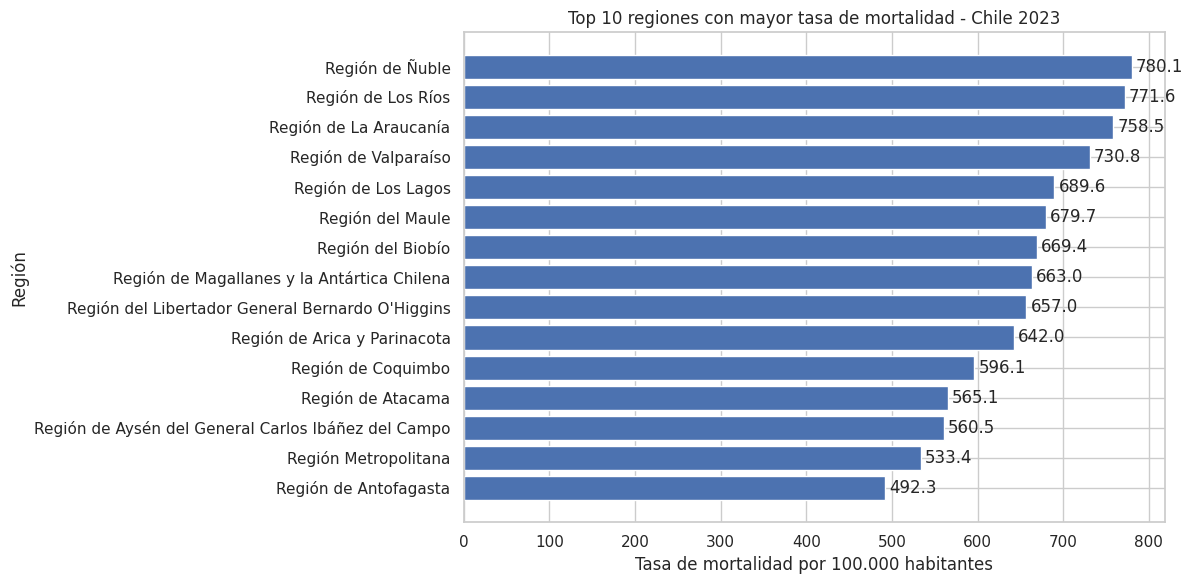

In [ ]:
import matplotlib.pyplot as plt

# Top regiones con mayor tasa de mortalidad
top10 = tabla_tasas.head(15)

plt.figure(figsize=(12,6))

plt.barh(
    top10["NOMBRE_REGION"],
    top10["Tasa_Mortalidad_100k"]
)

plt.xlabel("Tasa de mortalidad por 100.000 habitantes")
plt.ylabel("Región")
plt.title("Top 10 regiones con mayor tasa de mortalidad - Chile 2023")

# ── CORRECCIÓN: cambiar top por top10 ──
for i, valor in enumerate(top10["Tasa_Mortalidad_100k"]):
    plt.text(valor + 5, i, f"{valor:.1f}", va="center")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

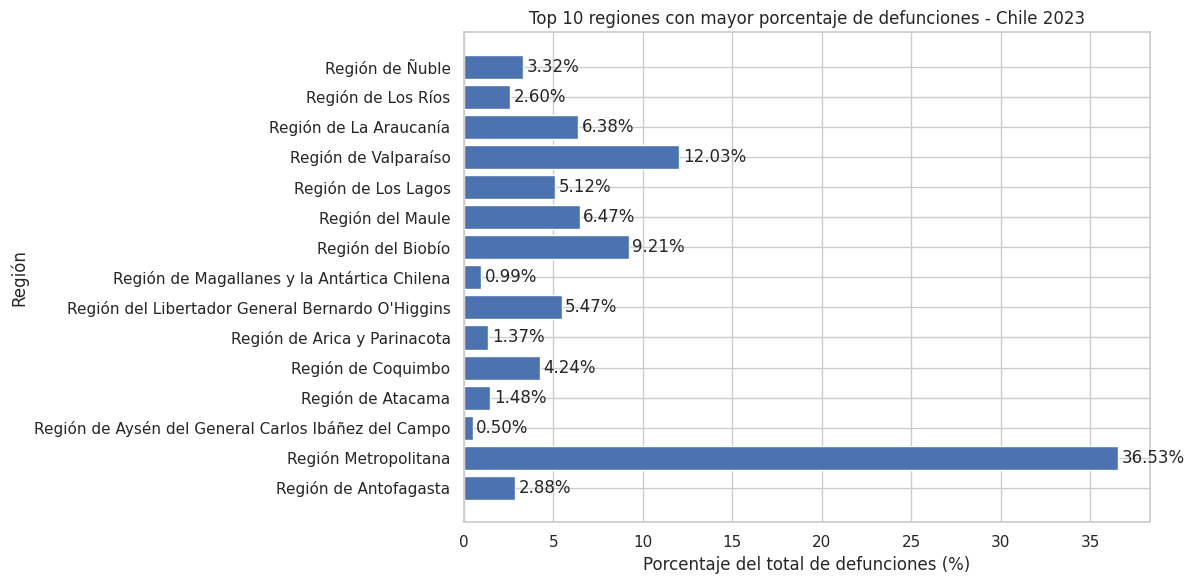

In [ ]:
import matplotlib.pyplot as plt

# Top 10 regiones con mayor porcentaje de defunciones
top10 = tabla_tasas.head(15)

plt.figure(figsize=(12,6))

plt.barh(
    top10["NOMBRE_REGION"],
    top10["Porcentaje_Defunciones"]
)

plt.xlabel("Porcentaje del total de defunciones (%)")
plt.ylabel("Región")
plt.title("Top 10 regiones con mayor porcentaje de defunciones - Chile 2023")

# Mostrar porcentaje al final de cada barra
for i, valor in enumerate(top10["Porcentaje_Defunciones"]):
    plt.text(valor + 0.2, i, f"{valor:.2f}%", va="center")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Interpretación — Gráficos de Tasa y Porcentaje de Defunciones por Región

#### Gráfico 1: Tasa de mortalidad por 100.000 habitantes

El gráfico revela que las regiones con mayor riesgo relativo de mortalidad se concentran en el sur de Chile:

- **Ñuble (780,1):** la región con mayor tasa del país a pesar de tener solo el 3,32% del total nacional. Su alta tasa se explica por una población envejecida y menor acceso a salud especializada.
- **Los Ríos (771,6) y La Araucanía (758,5):** completan el podio con características similares: zonas rurales, población adulta mayor y servicios de salud concentrados en pocas ciudades.
- **Magallanes (663,0) y Arica y Parinacota (642,0):** regiones extremas con poblaciones pequeñas pero tasas elevadas, reflejando el impacto del aislamiento geográfico en el acceso a salud.
- **Tarapacá (438,0):** la tasa más baja del país, consistente con una población predominantemente joven y activa económicamente en la industria minera.

---

#### Gráfico 2: Porcentaje del total nacional de defunciones

Este gráfico muestra una imagen completamente distinta al anterior, demostrando por qué ambas métricas son necesarias:

- **Región Metropolitana (36,53%):** concentra más de un tercio de todas las muertes del país en términos absolutos. Sin embargo su tasa (533,39) es la segunda más baja, confirmando que su alto conteo se debe exclusivamente a su tamaño poblacional.
- **Valparaíso (12,03%) y Biobío (9,21%):** segunda y tercera región con más defunciones absolutas, consistente con ser las regiones más pobladas fuera de la Metropolitana.
- **Aysén (0,50%) y Magallanes (0,99%):** los porcentajes más bajos del país por su baja densidad poblacional, aunque sus tasas relativas superan ampliamente a las regiones del norte.
- **Ñuble (3,32%):** aparece con porcentaje bajo en este gráfico pero lidera en el anterior — esta contradicción es la demostración más clara del valor del web scraping.

---

> **Insight para toma de decisiones:** una política de salud pública basada solo en volumen de defunciones priorizaría la Región Metropolitana. Una política basada en tasa relativa priorizaría Ñuble, Los Ríos y La Araucanía, donde el riesgo per cápita es hasta un 78% mayor que en Tarapacá. El análisis correcto requiere ambas perspectivas de forma complementaria.

## Exportación de Datos — Power BI

Para construir el panel de visualización en Power BI, exportamos un único CSV consolidado con toda la información necesaria: datos originales del DEIS, clusters asignados por K-Means y predicciones de edad generadas por la Regresión Lineal.

Este archivo permite crear en Power BI gráficos sincronizados con los resultados de todos los modelos entrenados en este notebook, cumpliendo el requisito de panel para apoyo a la toma de decisiones.

**Columnas exportadas:**

| Columna | Descripción |
|---|---|
| `AÑO`, `MES`, `MES_NOMBRE` | Temporalidad del fallecimiento |
| `NOMBRE_REGION` | Región donde ocurrió |
| `SEXO`, `EDAD`, `Tramo_Edad` | Perfil demográfico |
| `LUGAR_DEFUNCION` | Contexto del fallecimiento |
| `Causa_Principal` | Variable objetivo clasificada |
| `Cluster` | Grupo asignado por K-Means |
| `Pred_Edad_RegresionLineal` | Predicción del modelo de regresión |

In [ ]:
# ============================================================
# EXPORTACIÓN FINAL CORREGIDA — CSV PARA POWER BI
# ============================================================

df_powerbi = df_final.copy()
df_powerbi['NOMBRE_REGION'] = df_powerbi['NOMBRE_REGION'].replace(equivalencias)

# ── Clusters ─────────────────────────────────────────────────
df_powerbi = df_powerbi.join(cluster_df[['Cluster']], how='left')
df_powerbi['Cluster_Label']  = 'Cluster ' + df_powerbi['Cluster'].astype(str)
df_powerbi['Cluster_Perfil'] = df_powerbi['Cluster'].map({
    0: 'Hombre · 76 años · Neoplasias · Casa',
    1: 'Hombre · 44 años · Causas Externas · Otro',
    2: 'Mujer · 80 años · Neoplasias · Casa',
    3: 'Mujer · 77 años · Neoplasias · Casa'
})

# ── Predicción de edad ───────────────────────────────────────
X_pb = pd.get_dummies(
    df_powerbi[['SEXO','LUGAR_DEFUNCION','Causa_Principal','MES_NOMBRE','NOMBRE_REGION']],
    drop_first=True, dtype=int
)
X_pb = X_pb.reindex(columns=X_lr.columns, fill_value=0)
df_powerbi['Pred_Edad_RegresionLineal'] = modelo_lr.predict(X_pb).round(1)

# ── Merge con tasa de mortalidad ─────────────────────────────
df_powerbi = df_powerbi.merge(
    tabla_tasas[['NOMBRE_REGION','Tasa_Mortalidad_100k','Poblacion_2023']],
    on='NOMBRE_REGION', how='left'
)

# ── Corrección tasa: entero para evitar problema decimal ─────
df_powerbi['Tasa_Mortalidad_100k'] = df_powerbi['Tasa_Mortalidad_100k'].round(0).astype('Int64')
df_powerbi['Poblacion_2023']       = df_powerbi['Poblacion_2023'].round(0).astype('Int64')

# ── Columna orden tramo de edad ──────────────────────────────
orden_tramos = {
    '0-10':1,'11-20':2,'21-30':3,'31-40':4,'41-50':5,
    '51-60':6,'61-70':7,'71-80':8,'81-90':9,'91-100':10,'101+':11
}
df_powerbi['Orden_Tramo'] = df_powerbi['Tramo_Edad'].astype(str).map(orden_tramos).fillna(99).astype('Int64')

# ── Métricas reales de los modelos ───────────────────────────
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

mae_real        = round(mean_absolute_error(y_test_lr, y_pred_lr), 2)
r2_real         = round(r2_score(y_test_lr, y_pred_lr), 4)
rmse_real       = round(np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)), 2)
silhouette_real = round(silhouette_final, 4)
accuracy_real   = round(accuracy_score(y_test_clf, y_pred_clf), 4)
auc_real        = round(roc_auc_score(y_test_clf, y_prob_clf), 4)

print('=' * 50)
print('   MÉTRICAS REALES DE LOS MODELOS')
print('=' * 50)
print(f'  MAE  Regresión Lineal:  {mae_real}')
print(f'  R²   Regresión Lineal:  {r2_real}')
print(f'  RMSE Regresión Lineal:  {rmse_real}')
print(f'  Silhouette K-Means:     {silhouette_real}')
print(f'  Accuracy Clasificador:  {accuracy_real}')
print(f'  ROC-AUC Clasificador:   {auc_real}')
print('=' * 50)

# ── Exportar CSV ─────────────────────────────────────────────
columnas_finales = [
    'AÑO', 'MES', 'MES_NOMBRE',
    'NOMBRE_REGION', 'Tasa_Mortalidad_100k', 'Poblacion_2023',
    'SEXO', 'EDAD', 'Tramo_Edad', 'Orden_Tramo',
    'LUGAR_DEFUNCION', 'Causa_Principal',
    'Cluster', 'Cluster_Label', 'Cluster_Perfil',
    'Pred_Edad_RegresionLineal'
]

df_powerbi[columnas_finales].to_csv(
    'powerbi_fusionado.csv', index=False, encoding='utf-8-sig'
)

print(f'\n✅ powerbi_fusionado.csv exportado correctamente')
print(f'   Filas:    {len(df_powerbi):,}')
print(f'   Columnas: {len(columnas_finales)}')
print(f'   Nulos en Tasa: {df_powerbi["Tasa_Mortalidad_100k"].isnull().sum()}')
print(f'   Tasa Ñuble: {df_powerbi[df_powerbi["NOMBRE_REGION"]=="Región de Ñuble"]["Tasa_Mortalidad_100k"].iloc[0]}')
print(f'   Orden tramos únicos: {sorted(df_powerbi["Orden_Tramo"].dropna().unique().tolist())}')
display(df_powerbi[columnas_finales].head(3))

   MÉTRICAS REALES DE LOS MODELOS
  MAE  Regresión Lineal:  11.34
  R²   Regresión Lineal:  0.2656
  RMSE Regresión Lineal:  14.73
  Silhouette K-Means:     0.1814
  Accuracy Clasificador:  0.6368
  ROC-AUC Clasificador:   0.6925

✅ powerbi_fusionado.csv exportado correctamente
   Filas:    332,194
   Columnas: 16
   Nulos en Tasa: 51
   Tasa Ñuble: 780
   Orden tramos únicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 99]


,AÑO,MES,MES_NOMBRE,NOMBRE_REGION,Tasa_Mortalidad_100k,Poblacion_2023,SEXO,EDAD,Tramo_Edad,Orden_Tramo,LUGAR_DEFUNCION,Causa_Principal,Cluster,Cluster_Label,Cluster_Perfil,Pred_Edad_RegresionLineal
0,2026,3,Marzo,Región Metropolitana,533,8367790,Hombre,64,61-70,7,Hospital o Clínica,Enfermedades del Sistema Circulatorio,3,Cluster 3,Mujer · 77 años · Neoplasias · Casa,72.2
1,2026,3,Marzo,Región de Los Ríos,772,411205,Hombre,71,71-80,8,Casa habitación,Neoplasias (Cáncer y Tumores),3,Cluster 3,Mujer · 77 años · Neoplasias · Casa,71.2
2,2026,3,Marzo,Región del Biobío,669,1681430,Mujer,72,71-80,8,Hospital o Clínica,Enfermedades del Sistema Respiratorio,3,Cluster 3,Mujer · 77 años · Neoplasias · Casa,78.5


## Bonus — Exportación de Modelos en Archivo .PKL

El archivo `.pkl` (Pickle) es el estándar en Python para serializar objetos en memoria y guardarlos en disco. En el contexto de Machine Learning, permite **reutilizar modelos entrenados sin necesidad de re-ejecutar el notebook**, lo que es fundamental para integrarlos en sistemas productivos.

### ¿Qué contiene el PKL?

| Objeto | Descripción |
|---|---|
| `modelo_regresion_lineal` | Predice la edad de fallecimiento |
| `modelo_arbol_regresion` | Predice la edad (árbol de decisión) |
| `modelo_clasificador` | Predice la causa: Neoplasia vs Circulatorio |
| `modelo_kmeans` | Asigna el cluster poblacional |
| `scaler_kmeans` | Escalador necesario para K-Means |
| `columnas_regresion` | Estructura de columnas del modelo de regresión |
| `columnas_clasificacion` | Estructura de columnas del clasificador |

### ¿Para qué sirve en producción?

Sin el PKL, cualquier sistema externo tendría que re-entrenar los modelos desde cero con 407.897 registros cada vez que necesite una predicción. Con el PKL, la carga es instantánea y la predicción ocurre en milisegundos.

Este archivo fue integrado en una aplicación web Flask con temática del **Ministerio de Salud de Chile**, donde cualquier usuario puede ingresar variables sociodemográficas y obtener en tiempo real las 4 predicciones de los modelos.

In [ ]:
# ============================================================
# BONUS — EXPORTACIÓN DE MODELOS EN ARCHIVO .PKL
# ============================================================
# El archivo .pkl permite reutilizar los modelos entrenados
# sin tener que re-entrenarlos. Cualquier sistema externo
# (Flask, app web, formulario) puede cargarlo y predecir.

import pickle

# Guardamos todos los modelos y objetos necesarios en un solo archivo
modelos_bundle = {
    'modelo_regresion_lineal'  : modelo_lr,
    'modelo_arbol_regresion'   : arbol,
    'modelo_clasificador'      : clf,
    'modelo_kmeans'            : modelo_kmeans,
    'scaler_kmeans'            : scaler,
    'columnas_regresion'       : list(X_lr.columns),
    'columnas_clasificacion'   : list(X_clf.columns),
}

with open('modelos_defunciones.pkl', 'wb') as f:
    pickle.dump(modelos_bundle, f)

print('✅ modelos_defunciones.pkl exportado correctamente')
print(f'\nModelos incluidos en el PKL:')
for nombre in modelos_bundle.keys():
    print(f'  • {nombre}')

In [ ]:
# Verificamos que el PKL funciona cargándolo y haciendo una predicción
with open('modelos_defunciones.pkl', 'rb') as f:
    bundle_cargado = pickle.load(f)

# Predicción de prueba con la regresión lineal
modelo_cargado = bundle_cargado['modelo_regresion_lineal']
columnas       = bundle_cargado['columnas_regresion']

# Caso de prueba: mujer, hospital, neoplasia, enero, Metropolitana
caso_prueba = pd.DataFrame([{
    'SEXO'            : 'Mujer',
    'LUGAR_DEFUNCION' : 'Hospital o Clínica',
    'Causa_Principal' : 'Neoplasias (Cáncer y Tumores)',
    'MES_NOMBRE'      : 'Enero',
    'NOMBRE_REGION'   : 'Región Metropolitana'
}])

caso_encoded = pd.get_dummies(caso_prueba, drop_first=True, dtype=int)
caso_encoded = caso_encoded.reindex(columns=columnas, fill_value=0)

prediccion = modelo_cargado.predict(caso_encoded)[0]

print('=' * 55)
print('   VERIFICACIÓN DEL ARCHIVO .PKL')
print('=' * 55)
print(f'  Caso de prueba:')
print(f'    Sexo:    Mujer')
print(f'    Lugar:   Hospital o Clínica')
print(f'    Causa:   Neoplasias (Cáncer y Tumores)')
print(f'    Región:  Metropolitana')
print(f'    Mes:     Enero')
print(f'')
print(f'  Edad predicha: {prediccion:.1f} años')
print('=' * 55)
print('  ✅ PKL cargado y funcionando correctamente')
print('=' * 55)

## Conclusiones del Proyecto

Este proyecto analizó **332.194 defunciones** en Chile (2023-2026) mediante 4 modelos complementarios: Regresión Lineal, Árbol de Decisión, K-Means y un Clasificador binario.

**Principales hallazgos:**

- **Neoplasias y enfermedades circulatorias** concentran cerca del 50% de las muertes, siendo el principal desafío de salud pública del país.
- **K-Means identificó un cluster de riesgo prevenible**: hombres de ~44 años fallecidos por causas externas fuera de un hospital, contrastando fuertemente con los demás grupos (76-80 años, neoplasias, en domicilio).
- **Las métricas moderadas (R²≈0.27, MAE≈11 años) son esperables**: la edad de fallecimiento depende de factores no registrados en el certificado de defunción (hábitos, nivel socioeconómico, historial clínico), no de una falla del modelo.
- **El web scraping reveló una paradoja regional**: la RM concentra 36,5% de las muertes pero tiene baja tasa relativa (533/100k), mientras Ñuble, con solo 3,3% del volumen, tiene la tasa más alta (780/100k).

**Insights para la toma de decisiones:** priorizar prevención oncológica/cardiovascular, políticas dirigidas a hombres jóvenes (seguridad vial, salud mental), e inversión en salud para regiones del sur con mayor tasa de riesgo.


**Limitación:** al ser un registro administrativo, el dataset DEIS carece de variables clínicas que explicarían mejor la varianza en edad de fallecimiento — una oportunidad para trabajo futuro cruzando con encuestas de salud (ENS).

# Cosas a Agregar (justificar por que se utiliza estas metricas)

Clasificacion
- matriz de confusion
- acurracy
- precision
- re call
- f1 score
- curva roc y auc


Regresion
- MAE APLICADO
- MSE  (PENALISA MUCHO MAS LOS ERRORES)
- MMSE
- R2 (coeficiente de determinacion)  APLICADO

Agrupamiento

- Coeficiente de Silueta


Rúbrica 3 Evaluación:



- Trabajos corregidos en base al feedback 1° y 2° evaluación.
- Panel de Google Looker o Power BI con gráficos y visualización de resultados de sus colab para apoyar la toma de decisiones sincronizado.
- (BONUS) Web Scraping para aumentar sus dataset o para testear sus modelos con datos reales.
- (Bonus) Integración de su modelo en archivo .PKL en algún flujo de negocio - (habilitar algún API con Flask, integrarlo con un formulario web, app android, etc)
- set de datos de prueba.
- modelo k-means en todos los proyectos.
- Métricas específicas de evaluación de rendimiento de sus modelos regresión y/o clasificación.


Fecha de presentación: Martes 30 de junio y Jueves 2 de julio.



recordar

explicar por que los resultados son bajos, justificar las metricas de los modelos